In [10]:
from pathlib import Path
import pandas as pd
import numpy as np


cwd = Path.cwd()
print(cwd)
root=cwd.parents[2]
pd.set_option("display.max_columns",None)
display(root)

c:\Users\sebas\PycharmProjects\Git\Seb_branch\institutional-roi-analysis\notebooks\04_modeling\02_national_models


WindowsPath('c:/Users/sebas/PycharmProjects/Git/Seb_branch/institutional-roi-analysis')

### Feature Selection for Explanatory Model

Variables used in the initial prediction model (e.g., credential level, distance, and other structural constraints) were excluded from the explanatory model.

This is because the residuals already represent performance after controlling for these factors. Including them again would introduce circular reasoning and reduce the interpretability of the results.

Instead, the explanatory model focuses on institutional characteristics and program composition variables that were not used in the prediction stage, allowing us to better understand what drives over- and underperformance.

In [11]:
driver_df=pd.read_csv(root/'data'/'raw'/'scorecard'/'raw_national_inst_driver.csv')

In [12]:
driver_df["has_endowment"] = (
    driver_df["endowment_begin"].notna() &
    driver_df["endowment_end"].notna()
).astype(int)

In [13]:
driver_df["has_endowment"].describe()

count    6322.000000
mean        0.422018
std         0.493920
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         1.000000
Name: has_endowment, dtype: float64

In [14]:
driver_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6322 entries, 0 to 6321
Data columns (total 49 columns):
 #   Column                                                   Non-Null Count  Dtype  
---  ------                                                   --------------  -----  
 0   program_percentage_agriculture                           5582 non-null   float64
 1   program_percentage_resources                             5582 non-null   float64
 2   program_percentage_architecture                          5582 non-null   float64
 3   program_percentage_ethnic_cultural_gender                5582 non-null   float64
 4   program_percentage_communication                         5582 non-null   float64
 5   program_percentage_communications_technology             5582 non-null   float64
 6   program_percentage_computer                              5582 non-null   float64
 7   program_percentage_personal_culinary                     5582 non-null   float64
 8   program_percentage_education

In [25]:
ridge_residual_df = pd.read_csv(root/"data"/"raw"/"scorecard"/"raw_ridge_national_residual_programs.csv")
xgb_residual_df = pd.read_csv(root/"data"/"raw"/"scorecard"/"raw_xgb_national_residual_programs.csv")

In [26]:
ridge_residual_df['sign_agreement'] = (
    np.sign(ridge_residual_df['1_year_error_log']) == 
    np.sign(ridge_residual_df['4_year_error_log'])
) & (
    np.sign(ridge_residual_df['4_year_error_log']) == 
    np.sign(ridge_residual_df['5_year_error_log'])
)

print(ridge_residual_df['sign_agreement'].value_counts(normalize=True))

print(ridge_residual_df[['1_year_error','4_year_error','5_year_error']].corr())

sign_agreement
True     0.602308
False    0.397692
Name: proportion, dtype: float64
              1_year_error  4_year_error  5_year_error
1_year_error      1.000000      0.786356      0.695285
4_year_error      0.786356      1.000000      0.799308
5_year_error      0.695285      0.799308      1.000000


In [27]:
xgb_residual_df['sign_agreement'] = (
    np.sign(xgb_residual_df['1_year_error']) == 
    np.sign(xgb_residual_df['4_year_error'])
) & (
    np.sign(xgb_residual_df['4_year_error']) == 
    np.sign(xgb_residual_df['5_year_error'])
)

print(xgb_residual_df['sign_agreement'].value_counts(normalize=True))

print(xgb_residual_df[['1_year_error','4_year_error','5_year_error']].corr())

sign_agreement
True     0.520556
False    0.479444
Name: proportion, dtype: float64
              1_year_error  4_year_error  5_year_error
1_year_error      1.000000      0.684768      0.570242
4_year_error      0.684768      1.000000      0.663753
5_year_error      0.570242      0.663753      1.000000


In [118]:
ridge_residual_df['average_error_log'] = ridge_residual_df[
    ["1_year_error_log", "4_year_error_log", "5_year_error_log"]
].median(axis=1)

In [32]:
xgb_residual_df['total_pred'] = xgb_residual_df[
    ["1_year_pred", "4_year_pred", "5_year_pred"]
].sum(axis=1)

xgb_residual_df["total_count"] = (
    xgb_residual_df["1_yr_working_count"] +
    xgb_residual_df["4_yr_working_count"] +
    xgb_residual_df["5_yr_working_count"]
)

k = np.percentile(np.log1p(xgb_residual_df["total_count"]), 75)

xgb_residual_df["weight"] = (
    np.log1p(xgb_residual_df["total_count"]) /
    np.log1p(xgb_residual_df["total_count"] + k)
)

xgb_residual_df["combined_pct_error"] = xgb_residual_df[
    ["1_year_error", "4_year_error", "5_year_error"]
].median(axis=1) / xgb_residual_df['total_pred'] * 3

# consistent_mask = xgb_residual_df['sign_agreement'] == True
# xgb_residual_df = xgb_residual_df[consistent_mask]
# print(f"Consistent schools: {consistent_mask.sum()} of {len(xgb_residual_df)}")

xgb_residual_df.head()

,code,credential_level,unit_id,distance,school_type,5_yr_working_count,school_state,location_lat,location_lon,locale,carnegie_size_setting,admission_rate_overall,median_family_income,students_with_pell_grant,open_admissions_policy,age_entry,title_iv_eligibility_type,sat_scores_average_overall,act_scores_midpoint_cumulative,grad_students,selectivity_bucket,5_year_earning_log,5_year_pred_log,title,school_name,5_year_earning,5_year_pred,5_year_error,4_year_earning,4_year_earning_log,4_year_pred,4_year_pred_log,4_year_error,4_yr_working_count,1_year_earning,1_year_earning_log,1_year_pred,1_year_pred_log,1_year_error,1_yr_working_count,school_count,confidence,1_year_pct_error,1_year_score,4_year_pct_error,4_year_score,5_year_pct_error,5_year_score,rank_1,rank_4,rank_5,move_1_to_4,move_4_to_5,move_1_to_5,rank_std,rank_std_pct,mean_rank_std_pct,median_score,sign_agreement,total_pred,total_count,weight,combined_pct_error
0,100,3,110422,1,Public,21.0,CA,35.299513,-120.657311,23,16.0,0.3132,74513.0,0.455561,2.0,20.0,1,NaN,NaN,1036.0,mid,11.132397,11.181225,"Agriculture, General.",California Polytechnic State University-San Lu...,68350.0,71770.220,-3420.218750,84412.0,11.343465,70696.680,11.166154,13715.320313,36,64786.0,11.078845,46794.277,10.753516,17991.722656,18.0,28,high,0.384486,0.357262,0.194002,0.187573,-0.047655,-0.044850,2.0,2.0,14.0,0.0,12.0,12.0,6.928203,0.256600,0.191572,0.187573,False,189261.177,75.0,0.983097,0.217403
1,100,3,130934,1,Public,24.0,DE,39.187173,-75.540530,13,14.0,0.4658,39554.0,0.685488,2.0,20.0,1,940.0,NaN,746.0,mid,10.768022,10.906647,"Agriculture, General.",Delaware State University,47478.0,54537.656,-7059.656250,52676.0,10.871915,57368.062,10.957243,-4692.062500,24,38873.0,10.568055,38589.582,10.560738,283.417969,22.0,28,high,0.007344,0.006927,-0.081789,-0.077499,-0.129446,-0.122880,16.0,15.0,19.0,-1.0,4.0,3.0,2.081666,0.077099,0.191572,-0.077499,False,150495.300,70.0,0.981691,-0.093532
2,100,3,145813,1,Public,132.0,IL,40.509403,-88.990058,22,16.0,0.8815,67099.0,0.481270,2.0,20.0,1,1113.0,24.0,2439.0,open,11.067279,10.951448,"Agriculture, General.",Illinois State University,64041.0,57036.547,7004.453125,63600.0,11.060369,57882.055,10.966163,5717.945313,214,47295.0,10.764160,41597.434,10.635794,5697.566406,205.0,28,high,0.136969,0.136382,0.098786,0.098375,0.122806,0.121942,7.0,4.0,3.0,-3.0,-1.0,-4.0,2.081666,0.077099,0.191572,0.121942,True,156516.036,551.0,0.998326,0.109598
3,100,3,149222,1,Public,23.0,IL,37.714193,-89.217273,32,14.0,0.8688,37454.0,0.655376,2.0,22.0,1,1055.0,24.0,3237.0,open,11.051382,10.852016,"Agriculture, General.",Southern Illinois University-Carbondale,63031.0,51638.170,11392.828125,57596.0,10.961208,55643.027,10.926712,1952.972656,47,39700.0,10.589106,39304.938,10.579105,395.062500,22.0,28,high,0.010051,0.009480,0.035098,0.034243,0.220628,0.208893,15.0,6.0,1.0,-9.0,-5.0,-14.0,7.094599,0.262763,0.191572,0.034243,True,146586.135,92.0,0.986666,0.039969
4,100,3,149772,1,Public,145.0,IL,40.468086,-90.686899,33,13.0,0.7118,36222.0,0.684009,2.0,21.0,1,NaN,NaN,1807.0,open,10.971709,10.898309,"Agriculture, General.",Western Illinois University,58204.0,54084.820,4119.179687,58333.0,10.973923,54959.113,10.914345,3373.886719,160,48509.0,10.789505,38580.050,10.560491,9928.949219,149.0,28,high,0.257360,0.255759,0.061389,0.061031,0.076161,0.075681,4.0,5.0,8.0,1.0,3.0,4.0,2.081666,0.077099,0.191572,0.075681,True,147623.983,454.0,0.997908,0.083710


In [119]:
print("XGBoost residual std:", xgb_residual_df["combined_pct_error"].std())
print("Ridge residual std:  ", ridge_residual_df["average_error_log"].std())

XGBoost residual std: 0.1377109767007173
Ridge residual std:   0.1603396555596885


In [120]:
join_cols=["unit_id"]
for col in join_cols:
    driver_df[col] = driver_df[col].astype(str).str.strip()
    ridge_residual_df[col] = ridge_residual_df[col].astype(str).str.strip()


### Target Variable Selection

While a composite scoring metric was developed to rank program-level variability, it was not used as the target for the explanatory model.

Instead, the model uses the average  raw percentage error of years 1, 4, and 5 as the target:

  * pct_error = error / predicted

This decision ensures that the model learns directly from observed over- and underperformance, rather than from a derived metric that incorporates additional adjustments (e.g., sample size penalties and variability scaling).

The composite score remains useful for identifying high-variability groups, but the explanatory model focuses on the underlying performance signal.

In [121]:
# residual_df["combined_pct_error"]=(
#     residual_df[['1_year_error','4_year_error','5_year_error']].sum(axis=1)
#     /
#     residual_df[['1_year_pred','4_year_pred','5_year_pred']].sum(axis=1)
# )

In [154]:
# ridge_residual_df["log_error_median"] = ridge_residual_df[
#     ["1_year_error", "4_year_error", "5_year_error"]
# ].median(axis=1)

ridge_residual_df["log_pred_median"] = ridge_residual_df[
    ["1_year_pred_log", "4_year_pred_log", "5_year_pred_log"]
].median(axis=1)

# ridge_residual_df["row_pct_error"] = (
#    ridge_residual_df["dollar_error_median"] / ridge_residual_df["dollar_pred_median"]
# )

In [157]:
school_df = ridge_residual_df.groupby("unit_id", as_index=False).agg(
    average_error_log  =("average_error_log", "median"),
    average_pred_log =('log_pred_median', 'median'),
    avg_rank_stability=("mean_rank_std_pct", "mean"),
    school_name=("school_name", "first"),
    total_count_1=("1_yr_working_count", "sum"),
    total_count_4=("4_yr_working_count", "sum"),
    total_count_5=("5_yr_working_count", "sum"),
)

school_df["total_count"] = (
    school_df["total_count_1"] +
    school_df["total_count_4"] +
    school_df["total_count_5"]
)

k = np.percentile(np.log1p(school_df["total_count"]), 75)
school_df["weight"] = (
    np.log1p(school_df["total_count"]) /
    np.log1p(school_df["total_count"] + k)
)

In [159]:
targ="average_error_log"
merge_df=driver_df.merge(school_df[[targ,'unit_id','weight','average_pred_log']], on=["unit_id"],how="inner")
merge_df.head()

,program_percentage_agriculture,program_percentage_resources,program_percentage_architecture,program_percentage_ethnic_cultural_gender,program_percentage_communication,program_percentage_communications_technology,program_percentage_computer,program_percentage_personal_culinary,program_percentage_education,program_percentage_engineering,program_percentage_engineering_technology,program_percentage_language,program_percentage_family_consumer_science,program_percentage_legal,program_percentage_english,program_percentage_humanities,program_percentage_library,program_percentage_biological,program_percentage_mathematics,program_percentage_military,program_percentage_multidiscipline,program_percentage_parks_recreation_fitness,program_percentage_philosophy_religious,program_percentage_theology_religious_vocation,program_percentage_physical_science,program_percentage_science_technology,program_percentage_psychology,program_percentage_security_law_enforcement,program_percentage_public_administration_social_service,program_percentage_social_science,program_percentage_construction,program_percentage_mechanic_repair_technology,program_percentage_precision_production,program_percentage_transportation,program_percentage_visual_performing,program_percentage_health,program_percentage_business_marketing,program_percentage_history,instructional_expenditure_per_fte,faculty_salary,ft_faculty_rate,program_reporter_programs_offered,student_faculty_ratio,endowment_begin,endowment_end,dolflag,school_name,unit_id,has_endowment,average_error_log,weight,average_pred_log
0,0.0407,0.0000,0.0136,0.0000,0.0000,0.0542,0.0424,0.0,0.0424,0.1085,0.0203,0.0000,0.0186,0.0,0.0119,0.0661,0.0,0.1424,0.0051,0.0,0.0000,0.0373,0.0000,0.0,0.0237,0.0000,0.0559,0.0644,0.0441,0.0220,0.0,0.0,0.0,0.0,0.0186,0.0000,0.1678,0.0000,7254.0,8699.0,0.6439,NaN,19.0,NaN,NaN,0.0,Alabama A & M University,100654,0,-0.003805,0.999317,10.916022
1,0.0000,0.0000,0.0000,0.0007,0.0189,0.0000,0.0352,0.0,0.0541,0.0541,0.0000,0.0078,0.0000,0.0,0.0150,0.0303,0.0,0.1489,0.0055,0.0,0.0036,0.0000,0.0036,0.0,0.0176,0.0007,0.0762,0.0358,0.0163,0.0267,0.0,0.0,0.0,0.0,0.0274,0.2111,0.1997,0.0108,17855.0,12612.0,0.7704,NaN,18.0,7.393729e+08,8.589892e+08,0.0,University of Alabama at Birmingham,100663,1,-0.063918,0.999934,11.136193
2,0.0000,0.0000,0.0000,0.0000,0.0102,0.0000,0.0752,0.0,0.0223,0.3155,0.0122,0.0034,0.0020,0.0,0.0223,0.0000,0.0,0.0616,0.0156,0.0,0.0156,0.0271,0.0007,0.0,0.0427,0.0000,0.0251,0.0000,0.0000,0.0156,0.0,0.0,0.0,0.0,0.0413,0.1043,0.1774,0.0102,9877.0,10639.0,0.6590,NaN,17.0,9.962702e+07,1.137376e+08,1.0,University of Alabama in Huntsville,100706,1,-0.034837,0.999451,11.371226
3,0.0000,0.0000,0.0000,0.0000,0.0511,0.0000,0.0404,0.0,0.0745,0.0128,0.0000,0.0000,0.0000,0.0,0.0085,0.0000,0.0,0.1085,0.0064,0.0,0.0979,0.0128,0.0000,0.0,0.0213,0.0000,0.0638,0.1234,0.0383,0.0298,0.0,0.0,0.0,0.0,0.1043,0.0872,0.1191,0.0000,10723.0,8153.0,0.6477,NaN,15.0,1.186163e+08,1.351989e+08,0.0,Alabama State University,100724,1,0.016162,0.999299,10.752731
4,0.0000,0.0068,0.0000,0.0014,0.0950,0.0000,0.0163,0.0,0.0250,0.1002,0.0000,0.0033,0.0628,0.0,0.0098,0.0002,0.0,0.0375,0.0080,0.0,0.0138,0.0392,0.0021,0.0,0.0098,0.0000,0.0517,0.0000,0.0100,0.0900,0.0,0.0,0.0,0.0,0.0241,0.0920,0.2911,0.0100,9728.0,11419.0,0.7904,NaN,19.0,1.369440e+09,1.565892e+09,1.0,The University of Alabama,100751,1,-0.059677,0.999954,11.089408


In [160]:
model_df=merge_df.copy()
print("scorecard driver schools:", driver_df['unit_id'].nunique())
print("school_df school:", school_df['unit_id'].nunique())
print("model_df schools:", model_df['unit_id'].nunique())

print("model_df columns:")
print(sorted(model_df.columns.tolist()))

scorecard driver schools: 6322
school_df school: 4327
model_df schools: 4327
model_df columns:
['average_error_log', 'average_pred_log', 'dolflag', 'endowment_begin', 'endowment_end', 'faculty_salary', 'ft_faculty_rate', 'has_endowment', 'instructional_expenditure_per_fte', 'program_percentage_agriculture', 'program_percentage_architecture', 'program_percentage_biological', 'program_percentage_business_marketing', 'program_percentage_communication', 'program_percentage_communications_technology', 'program_percentage_computer', 'program_percentage_construction', 'program_percentage_education', 'program_percentage_engineering', 'program_percentage_engineering_technology', 'program_percentage_english', 'program_percentage_ethnic_cultural_gender', 'program_percentage_family_consumer_science', 'program_percentage_health', 'program_percentage_history', 'program_percentage_humanities', 'program_percentage_language', 'program_percentage_legal', 'program_percentage_library', 'program_percentage

In [161]:
model_df=model_df.drop(columns=[
    # "program_reporter_programs_offered",
    # 'code',
    # 'unit_id',
    # 'school_name'
    ]
)

In [162]:
program_cols = [c for c in model_df.columns if c.startswith("program_percentage_")]

for c in program_cols:
    model_df[c] = pd.to_numeric(model_df[c], errors="coerce").fillna(0)

# STEM
model_df["pct_stem"] = model_df[
    [
        "program_percentage_computer",
        "program_percentage_engineering",
        "program_percentage_engineering_technology",
        "program_percentage_mathematics",
        "program_percentage_physical_science",
        "program_percentage_biological",
        "program_percentage_science_technology"
    ]
].sum(axis=1)

# Business / Econ
model_df["pct_business"] = model_df[
    ["program_percentage_business_marketing"]
].sum(axis=1)

# Health
model_df["pct_health"] = model_df[
    ["program_percentage_health"]
].sum(axis=1)

# Social Sciences
model_df["pct_social_science"] = model_df[
    [
        "program_percentage_psychology",
        "program_percentage_social_science",
        "program_percentage_history",
        "program_percentage_public_administration_social_service"
    ]
].sum(axis=1)

# Humanities
model_df["pct_humanities"] = model_df[
    [
        "program_percentage_english",
        "program_percentage_language",
        "program_percentage_humanities",
        "program_percentage_philosophy_religious",
        "program_percentage_theology_religious_vocation",
        "program_percentage_ethnic_cultural_gender"
    ]
].sum(axis=1)

# Arts & Communication
model_df["pct_arts_comm"] = model_df[
    [
        "program_percentage_visual_performing",
        "program_percentage_communication"
    ]
].sum(axis=1)

# Education
model_df["pct_education"] = model_df[
    ["program_percentage_education"]
].sum(axis=1)

# Trades / Technical
model_df["pct_trades"] = model_df[
    [
        "program_percentage_construction",
        "program_percentage_mechanic_repair_technology",
        "program_percentage_precision_production",
        "program_percentage_transportation"
    ]
].sum(axis=1)

# Services / Consumer
model_df["pct_services"] = model_df[
    [
        "program_percentage_personal_culinary",
        "program_percentage_family_consumer_science",
        "program_percentage_parks_recreation_fitness"
    ]
].sum(axis=1)

# Law / Security
model_df["pct_law_security"] = model_df[
    [
        "program_percentage_legal",
        "program_percentage_security_law_enforcement"
    ]
].sum(axis=1)

# Agriculture / Natural resources
model_df["pct_agriculture"] = model_df[
    [
        # "program_percentage_agriculture",
        "program_percentage_resources"
    ]
].sum(axis=1)

model_df["pct_high_roi"] = (
    model_df["program_percentage_engineering"] +
    model_df["program_percentage_computer"] +
    model_df["program_percentage_health"]
)

model_df["pct_low_roi"] = (
    model_df["program_percentage_education"] +
    model_df["program_percentage_personal_culinary"] +
    model_df["program_percentage_humanities"]
)

model_df["program_hhi"] = (model_df[program_cols] ** 2).sum(axis=1)

model_df["max_program_share"] = model_df[program_cols].max(axis=1)

model_df["high_roi_x_concentration"] = (
    model_df["pct_high_roi"] * model_df["program_hhi"]
)

# model_df = model_df.drop(columns=program_cols)



In [163]:
display("Repeated columns within instituions",(model_df.groupby("unit_id").nunique() > 1).sum())

'Repeated columns within instituions'

program_percentage_agriculture               0
program_percentage_resources                 0
program_percentage_architecture              0
program_percentage_ethnic_cultural_gender    0
program_percentage_communication             0
                                            ..
pct_high_roi                                 0
pct_low_roi                                  0
program_hhi                                  0
max_program_share                            0
high_roi_x_concentration                     0
Length: 67, dtype: int64

In [164]:
inst_model_df = model_df.drop_duplicates(subset="unit_id").reset_index(drop=True)
print("inst_model_df shape:", inst_model_df.shape)
display(inst_model_df.head())

inst_model_df shape: (4327, 68)


,program_percentage_agriculture,program_percentage_resources,program_percentage_architecture,program_percentage_ethnic_cultural_gender,program_percentage_communication,program_percentage_communications_technology,program_percentage_computer,program_percentage_personal_culinary,program_percentage_education,program_percentage_engineering,program_percentage_engineering_technology,program_percentage_language,program_percentage_family_consumer_science,program_percentage_legal,program_percentage_english,program_percentage_humanities,program_percentage_library,program_percentage_biological,program_percentage_mathematics,program_percentage_military,program_percentage_multidiscipline,program_percentage_parks_recreation_fitness,program_percentage_philosophy_religious,program_percentage_theology_religious_vocation,program_percentage_physical_science,program_percentage_science_technology,program_percentage_psychology,program_percentage_security_law_enforcement,program_percentage_public_administration_social_service,program_percentage_social_science,program_percentage_construction,program_percentage_mechanic_repair_technology,program_percentage_precision_production,program_percentage_transportation,program_percentage_visual_performing,program_percentage_health,program_percentage_business_marketing,program_percentage_history,instructional_expenditure_per_fte,faculty_salary,ft_faculty_rate,program_reporter_programs_offered,student_faculty_ratio,endowment_begin,endowment_end,dolflag,school_name,unit_id,has_endowment,average_error_log,weight,average_pred_log,pct_stem,pct_business,pct_health,pct_social_science,pct_humanities,pct_arts_comm,pct_education,pct_trades,pct_services,pct_law_security,pct_agriculture,pct_high_roi,pct_low_roi,program_hhi,max_program_share,high_roi_x_concentration
0,0.0407,0.0000,0.0136,0.0000,0.0000,0.0542,0.0424,0.0,0.0424,0.1085,0.0203,0.0000,0.0186,0.0,0.0119,0.0661,0.0,0.1424,0.0051,0.0,0.0000,0.0373,0.0000,0.0,0.0237,0.0000,0.0559,0.0644,0.0441,0.0220,0.0,0.0,0.0,0.0,0.0186,0.0000,0.1678,0.0000,7254.0,8699.0,0.6439,NaN,19.0,NaN,NaN,0.0,Alabama A & M University,100654,0,-0.003805,0.999317,10.916022,0.3424,0.1678,0.0000,0.1220,0.0780,0.0186,0.0424,0.0,0.0559,0.0644,0.0000,0.1509,0.1085,0.085876,0.1678,0.012959
1,0.0000,0.0000,0.0000,0.0007,0.0189,0.0000,0.0352,0.0,0.0541,0.0541,0.0000,0.0078,0.0000,0.0,0.0150,0.0303,0.0,0.1489,0.0055,0.0,0.0036,0.0000,0.0036,0.0,0.0176,0.0007,0.0762,0.0358,0.0163,0.0267,0.0,0.0,0.0,0.0,0.0274,0.2111,0.1997,0.0108,17855.0,12612.0,0.7704,NaN,18.0,7.393729e+08,8.589892e+08,0.0,University of Alabama at Birmingham,100663,1,-0.063918,0.999934,11.136193,0.2620,0.1997,0.2111,0.1300,0.0574,0.0463,0.0541,0.0,0.0000,0.0358,0.0000,0.3004,0.0844,0.124569,0.2111,0.037421
2,0.0000,0.0000,0.0000,0.0000,0.0102,0.0000,0.0752,0.0,0.0223,0.3155,0.0122,0.0034,0.0020,0.0,0.0223,0.0000,0.0,0.0616,0.0156,0.0,0.0156,0.0271,0.0007,0.0,0.0427,0.0000,0.0251,0.0000,0.0000,0.0156,0.0,0.0,0.0,0.0,0.0413,0.1043,0.1774,0.0102,9877.0,10639.0,0.6590,NaN,17.0,9.962702e+07,1.137376e+08,1.0,University of Alabama in Huntsville,100706,1,-0.034837,0.999451,11.371226,0.5228,0.1774,0.1043,0.0509,0.0264,0.0515,0.0223,0.0,0.0291,0.0000,0.0000,0.4950,0.0223,0.158330,0.3155,0.078373
3,0.0000,0.0000,0.0000,0.0000,0.0511,0.0000,0.0404,0.0,0.0745,0.0128,0.0000,0.0000,0.0000,0.0,0.0085,0.0000,0.0,0.1085,0.0064,0.0,0.0979,0.0128,0.0000,0.0,0.0213,0.0000,0.0638,0.1234,0.0383,0.0298,0.0,0.0,0.0,0.0,0.1043,0.0872,0.1191,0.0000,10723.0,8153.0,0.6477,NaN,15.0,1.186163e+08,1.351989e+08,0.0,Alabama State University,100724,1,0.016162,0.999299,10.752731,0.1894,0.1191,0.0872,0.1319,0.0085,0.1554,0.0745,0.0,0.0128,0.1234,0.0000,0.1404,0.0745,0.086365,0.1234,0.012126
4,0.0000,0.0068,0.0000,0.0014,0.0950,0.0000,0.0163,0.0,0.0250,0.1002,0.0000,0.0033,0.0628,0.0,0.0098,0.0002,0.0,0.0375,0.0080,0.0,0.0138,0.0392,0.0021,0.0,0.0098,0.0000,0.0517,0.0000,0.0100,0.0900,0.0,0.0,0.0,0.0,0.0241,0.0920,0.2911,0.0100,9728.0,11419.0,0.7904,NaN,19.0,1.369440e+09,

In [165]:
display(inst_model_df.describe())
numeric_cols = inst_model_df.select_dtypes(include=[np.number]).columns.tolist()
display("Feature correlation to target variable",
        inst_model_df[numeric_cols].corr()[targ].sort_values())
display(inst_model_df.info())

,program_percentage_agriculture,program_percentage_resources,program_percentage_architecture,program_percentage_ethnic_cultural_gender,program_percentage_communication,program_percentage_communications_technology,program_percentage_computer,program_percentage_personal_culinary,program_percentage_education,program_percentage_engineering,program_percentage_engineering_technology,program_percentage_language,program_percentage_family_consumer_science,program_percentage_legal,program_percentage_english,program_percentage_humanities,program_percentage_library,program_percentage_biological,program_percentage_mathematics,program_percentage_military,program_percentage_multidiscipline,program_percentage_parks_recreation_fitness,program_percentage_philosophy_religious,program_percentage_theology_religious_vocation,program_percentage_physical_science,program_percentage_science_technology,program_percentage_psychology,program_percentage_security_law_enforcement,program_percentage_public_administration_social_service,program_percentage_social_science,program_percentage_construction,program_percentage_mechanic_repair_technology,program_percentage_precision_production,program_percentage_transportation,program_percentage_visual_performing,program_percentage_health,program_percentage_business_marketing,program_percentage_history,instructional_expenditure_per_fte,faculty_salary,ft_faculty_rate,program_reporter_programs_offered,student_faculty_ratio,endowment_begin,endowment_end,dolflag,has_endowment,average_error_log,weight,average_pred_log,pct_stem,pct_business,pct_health,pct_social_science,pct_humanities,pct_arts_comm,pct_education,pct_trades,pct_services,pct_law_security,pct_agriculture,pct_high_roi,pct_low_roi,program_hhi,max_program_share,high_roi_x_concentration
count,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4321.000000,3072.000000,2912.000000,1409.000000,4202.000000,2.251000e+03,2.251000e+03,4267.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000
mean,0.011191,0.004211,0.001552,0.001072,0.012648,0.003737,0.029479,0.181065,0.025790,0.013613,0.014441,0.002416,0.005930,0.002744,0.006132,0.067669,0.000057,0.024271,0.003424,0.000409,0.011485,0.012945,0.003921,0.005529,0.004854,0.000808,0.026518,0.020064,0.007920,0.018383,0.016018,0.032422,0.016612,0.009413,0.027515,0.248758,0.091439,0.003968,9980.008794,8333.480143,0.607719,5.617459,16.342932,3.669611e+08,3.925047e+08,0.434263,0.520222,0.007483,0.996526,10.711968,0.090889,0.091439,0.248758,0.056788,0.086738,0.040163,0.025790,0.074465,0.199940,0.022807,0.004211,0.291849,0.274524,0.469220,0.554762,0.165711
std,0.058359,0.018008,0.018414,0.006609,0.044013,0.032788,0.060959,0.369368,0.057262,0.055116,0.048717,0.007959,0.021419,0.026339,0.017487,0.142046,0.001136,0.053937,0.009208,0.008323,0.033631,0.033141,0.048856,0.055035,0.017323,0.007763,0.057192,0.045781,0.027099,0.046114,0.072963,0.116686,0.068208,0.064500,0.099337,0.322664,0.125168,0.009037,15447.418759,2838.348431,0.277490,5.893275,7.694457,2.154191e+09,2.249583e+09,0.495718,0.499649,0.143179,0.005290,0.429910,0.132947,0.125168,0.322664,0.097986,0.158910,0.111651,0.057262,0.192851,0.362832,0.053301,0.018008,0.319469,0.358955,0.377284,0.337549,0.310759
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000

'Feature correlation to target variable'

program_percentage_philosophy_religious         -0.096894
program_percentage_health                       -0.095363
pct_health                                      -0.095363
pct_high_roi                                    -0.091017
high_roi_x_concentration                        -0.070186
                                                   ...   
pct_law_security                                 0.062809
pct_low_roi                                      0.073836
program_percentage_mechanic_repair_technology    0.074339
faculty_salary                                   0.159494
average_error_log                                1.000000
Name: average_error_log, Length: 66, dtype: float64

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4327 entries, 0 to 4326
Data columns (total 68 columns):
 #   Column                                                   Non-Null Count  Dtype  
---  ------                                                   --------------  -----  
 0   program_percentage_agriculture                           4327 non-null   float64
 1   program_percentage_resources                             4327 non-null   float64
 2   program_percentage_architecture                          4327 non-null   float64
 3   program_percentage_ethnic_cultural_gender                4327 non-null   float64
 4   program_percentage_communication                         4327 non-null   float64
 5   program_percentage_communications_technology             4327 non-null   float64
 6   program_percentage_computer                              4327 non-null   float64
 7   program_percentage_personal_culinary                     4327 non-null   float64
 8   program_percentage_education

None

In [166]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
from sklearn.impute import SimpleImputer

def run_school_corr_screen(merge_df, feature_cols, target_col="average_error_log", weight_col="weight"):
    # 1. Fix Duplicates: Keep only the first occurrence of any column name
    df_clean = merge_df.loc[:, ~merge_df.columns.duplicated()].copy()
    
    # 2. Setup Temporary DF
    cols_to_keep = [c for c in feature_cols if c in df_clean.columns] + [target_col, weight_col]
    df_tmp = df_clean[cols_to_keep].copy()
    
    # 3. Clean Missing Data
    df_tmp = df_tmp.dropna(subset=[target_col])
    df_tmp = df_tmp.dropna(subset=feature_cols, how="all")
    
    print(f"Rows after dropna: {len(df_tmp)}")
    print(f"Features: {len(feature_cols)}")
    
    # 4. Robust Clipping (Fixes the TypeError)
    # .quantile() can return a Series if target_col isn't unique, but we fixed that above.
    # We use .item() to ensure we get a single Python number.
    lo = df_tmp[target_col].quantile(0.02)
    hi = df_tmp[target_col].quantile(0.98)
    
    lo_val = lo.item() if hasattr(lo, 'item') else float(lo)
    hi_val = hi.item() if hasattr(hi, 'item') else float(hi)

    print(f"Target distribution (Clipped at {lo_val:.4f}, {hi_val:.4f}):")
    print(f"{df_tmp[target_col].describe().round(4)}\n")

    df_tmp[target_col] = df_tmp[target_col].clip(lower=lo_val, upper=hi_val)

    # 5. Prepare X, y, w
    X = df_tmp[feature_cols].apply(pd.to_numeric, errors="coerce")
    y = df_tmp[target_col]
    w = df_tmp[weight_col]

    # 6. Correlation Screen
    corr = X.corrwith(y).abs().sort_values(ascending=False)
    
    print("Top 15 correlations with target:")
    print(corr.head(15).round(4).to_string())
    print(f"\nFeatures with |corr| > 0.10: {(corr > 0.10).sum()}")
    print(f"Features with |corr| > 0.15: {(corr > 0.15).sum()}")
    print(f"Features with |corr| > 0.20: {(corr > 0.20).sum()}")

    # 7. Simple Imputation for RF
    imputer = SimpleImputer(strategy="median")
    X_imp_arr = imputer.fit_transform(X)
    X_imp = pd.DataFrame(X_imp_arr, columns=X.columns, index=X.index)

    # 8. Cross-Validated Random Forest
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    rf = RandomForestRegressor(
        n_estimators=100, 
        max_depth=3,
        random_state=42, 
        n_jobs=-1
    )

    fold_r2s = []
    # Use index-based splitting for safety with Series
    for train_idx, val_idx in kf.split(X_imp):
        X_tr, X_val = X_imp.iloc[train_idx], X_imp.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
        w_tr, w_val = w.iloc[train_idx], w.iloc[val_idx]

        rf.fit(X_tr, y_tr, sample_weight=w_tr)
        y_pred = rf.predict(X_val)
        # Weight the R2 score to trust larger schools in the validation too
        fold_r2s.append(r2_score(y_val, y_pred, sample_weight=w_val))

    print(f"\nRF CV R² (max_depth=3): {np.mean(fold_r2s):.4f} ± {np.std(fold_r2s):.4f}")
    print(f"Fold R²s: {[round(s,3) for s in fold_r2s]}")

    # 9. Feature Importances
    if np.mean(fold_r2s) > -1: # Changed from 0 to -1 to show importance even if R2 is low
        rf.fit(X_imp, y, sample_weight=w)
        imp_df = pd.DataFrame({
            "feature": X.columns,
            "importance": rf.feature_importances_
        }).sort_values("importance", ascending=False)
        print("\nTop 10 feature importances:")
        print(imp_df.head(10).to_string(index=False))

    return corr

# Ensure you define feature_cols carefully
# Make sure "average_error_log" isn't in this list or it will have a 1.0 correlation!
exclude_list = [
    "unit_id", "school_name", "weight", "combined_pct_error",
    "avg_rank_stability", "total_pred", "median_error",
    "total_count", "total_count_1", "total_count_4", "total_count_5",
    "1_year_error_log", "4_year_error_log", "5_year_error_log", "average_error_log"
]

feature_cols = [c for c in inst_model_df.columns if c not in exclude_list]

corr_results = run_school_corr_screen(inst_model_df, feature_cols)

Rows after dropna: 4327
Features: 64
Target distribution (Clipped at -0.3122, 0.3100):
count    4327.0000
mean        0.0075
std         0.1432
min        -0.7335
25%        -0.0664
50%         0.0053
75%         0.0809
max         1.1397
Name: average_error_log, dtype: float64

Top 15 correlations with target:
faculty_salary                                   0.1613
program_percentage_health                        0.1025
pct_health                                       0.1025
pct_high_roi                                     0.0977
pct_low_roi                                      0.0974
program_percentage_personal_culinary             0.0826
pct_services                                     0.0819
program_percentage_mechanic_repair_technology    0.0760
high_roi_x_concentration                         0.0742
pct_arts_comm                                    0.0710
program_percentage_visual_performing             0.0677
ft_faculty_rate                                  0.0644
program_percent

In [ ]:
from sklearn.model_selection import GridSearchCV, KFold, train_test_split
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, GridSearchCV, StratifiedKFold
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, r2_score

RANDOM_STATE = 42

In [ ]:
feature_cols = [c for c in inst_model_df.columns if c not in ["unit_id", targ, "weight",'credential_level','code','avg_rank_stability','school_name','average_pred_log']]

X = inst_model_df[feature_cols]

y = inst_model_df[targ]
# y = y.clip(upper=y.quantile(0.9))

w = inst_model_df["weight"]

X = X.apply(pd.to_numeric, errors="coerce")

X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X, y, w, test_size=0.2, random_state=RANDOM_STATE
)

num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, num_cols)
])

In [170]:
len(y)

4327

In [135]:
ridge_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("reg", Ridge())
])

# ridge_model = TransformedTargetRegressor(
#     regressor=ridge_pipe,
#     transformer=PowerTransformer(method="yeo-johnson", standardize=False)
# )

ridge_param_grid = {
    "reg__alpha": [0.01, 0.1, 1.0, 1.5, 2.0, 2.5, 3.0]
}

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

ridge_grid = GridSearchCV(
    estimator=ridge_pipe,
    param_grid=ridge_param_grid,
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=1,
    refit=True,
    verbose=1,
    error_score="raise"
)

ridge_grid.fit(
    X_train,
    y_train,
    reg__sample_weight=w_train
)

ridge_best = ridge_grid.best_estimator_
ridge_preds = ridge_best.predict(X_test)

print("RIDGE")
print("Best params:", ridge_grid.best_params_)
print("Best CV MAE:", round(-ridge_grid.best_score_, 4))
print("Test MAE (vs unclipped y_test):", round(mean_absolute_error(y_test, ridge_preds), 4))
print("Test R2 (vs unclipped y_test):", round(r2_score(y_test, ridge_preds), 4))

# feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()
# print(feature_names)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
RIDGE
Best params: {'reg__alpha': 0.1}
Best CV MAE: 0.0998
Test MAE (vs unclipped y_test): 0.1
Test R2 (vs unclipped y_test): 0.0376


In [136]:
from sklearn.linear_model import Lasso


lasso_param_grid = {
    "reg__alpha": np.logspace(-4, 1, 50)
}

lasso_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("reg", Lasso(max_iter=10000, random_state=RANDOM_STATE))
])

lasso_grid = GridSearchCV(
    estimator=lasso_pipe,
    param_grid=lasso_param_grid,
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=1,
    refit=True,
    verbose=1,
    error_score="raise"
)

lasso_grid.fit(
    X_train,
    y_train,
    reg__sample_weight=w_train
)

lasso_best = lasso_grid.best_estimator_
lasso_preds = lasso_best.predict(X_test)

print("Test MAE (vs unclipped y_test):", round(mean_absolute_error(y_test, lasso_preds), 4))
print("Test R2 (vs unclipped y_test):", round(r2_score(y_test, lasso_preds), 4))

# feature_names = lasso_best.named_steps["preprocessor"].get_feature_names_out()

# coef_df = pd.DataFrame({
#     "feature": [f.replace("num__", "") for f in feature_names],
#     "coefficient": lasso_best.named_steps["reg"].coef_
# }).sort_values("coefficient", key=abs, ascending=False)

# print(coef_df[coef_df["coefficient"] != 0].to_string(index=False))
# print(f"\nFeatures selected: {(coef_df['coefficient'] != 0).sum()} of {len(coef_df)}")
# print(f"Lasso alpha chosen: {lasso_best.named_steps['reg'].alpha:.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Test MAE (vs unclipped y_test): 0.0996
Test R2 (vs unclipped y_test): 0.0406


In [137]:
from sklearn.linear_model import LassoCV

for seed in [0, 7, 13, 21, 99]:
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("reg", LassoCV(cv=5, random_state=seed, max_iter=50000))
    ])
    pipe.fit(X_train, y_train, reg__sample_weight=w_train)

    feature_names = pipe.named_steps["preprocessor"].get_feature_names_out()
    selected = [
        f.replace("num__", "")
        for f, c in zip(feature_names, pipe.named_steps["reg"].coef_)
        if c != 0
    ]
    print(f"Seed {seed:3d}: {selected}")

Seed   0: ['program_percentage_agriculture', 'program_percentage_resources', 'program_percentage_architecture', 'program_percentage_engineering_technology', 'program_percentage_family_consumer_science', 'program_percentage_english', 'program_percentage_humanities', 'program_percentage_military', 'program_percentage_philosophy_religious', 'program_percentage_science_technology', 'program_percentage_security_law_enforcement', 'program_percentage_public_administration_social_service', 'program_percentage_social_science', 'program_percentage_construction', 'program_percentage_mechanic_repair_technology', 'program_percentage_precision_production', 'program_percentage_health', 'instructional_expenditure_per_fte', 'faculty_salary', 'ft_faculty_rate', 'student_faculty_ratio', 'endowment_end', 'pct_arts_comm', 'pct_high_roi', 'pct_low_roi', 'max_program_share']
Seed   7: ['program_percentage_agriculture', 'program_percentage_resources', 'program_percentage_architecture', 'program_percentage_eng

In [138]:
from sklearn.linear_model import RidgeCV

stable_features = [
    'program_percentage_agriculture', 'program_percentage_resources', 'program_percentage_architecture', 
    'program_percentage_ethnic_cultural_gender', 'program_percentage_communication',
    'program_percentage_communications_technology', 'program_percentage_computer', 
    'program_percentage_education', 'program_percentage_language', 'program_percentage_legal', 
    'program_percentage_english', 'program_percentage_library', 'program_percentage_biological',
    'program_percentage_multidiscipline', 'program_percentage_parks_recreation_fitness', 
    'program_percentage_philosophy_religious', 'program_percentage_theology_religious_vocation',
    'program_percentage_physical_science', 'program_percentage_science_technology',
    'program_percentage_security_law_enforcement', 'program_percentage_public_administration_social_service',
    'program_percentage_construction', 'program_percentage_precision_production',
    'program_percentage_transportation', 'program_percentage_business_marketing',
    'program_percentage_history', 'instructional_expenditure_per_fte', 'faculty_salary',
    'ft_faculty_rate', 'program_reporter_programs_offered', 'student_faculty_ratio',
    'endowment_begin', 'dolflag', 'has_endowment', 'pct_stem', 'pct_business',
    'pct_trades', 'pct_services', 'pct_agriculture', 'pct_high_roi', 'pct_low_roi', 
    'program_hhi', 'max_program_share'
]

pipe_final = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("ridge", RidgeCV(alphas=np.logspace(-2, 3, 50), cv=5))
])

pipe_final.fit(X_train[stable_features], y_train, ridge__sample_weight=w_train)

y_pred = pipe_final.predict(X_test[stable_features])
print("Final R²:", round(r2_score(y_test, y_pred), 4))
print("Final MAE:", round(mean_absolute_error(y_test, y_pred), 4))

coef_df = pd.DataFrame({
    "feature": stable_features,
    "coefficient": pipe_final.named_steps["ridge"].coef_
}).sort_values("coefficient", ascending=False)
print(coef_df.to_string(index=False))

Final R²: 0.0388
Final MAE: 0.1005
                                                feature  coefficient
                                         faculty_salary     0.014984
                                             pct_trades     0.010086
            program_percentage_security_law_enforcement     0.006940
                                            pct_low_roi     0.005087
                  program_percentage_science_technology     0.005086
                                      max_program_share     0.004482
                        program_percentage_architecture     0.003934
                                               pct_stem     0.002987
                             program_percentage_history     0.002870
                      instructional_expenditure_per_fte     0.002529
                                            program_hhi     0.002345
                     program_percentage_multidiscipline     0.002308
                           program_percentage_education     0.002282

In [139]:
pipe_final.fit(X_train[stable_features], y_train)
y_pred = pipe_final.predict(X_test[stable_features])
print("R² no weights:", round(r2_score(y_test, y_pred), 4))

from sklearn.linear_model import Ridge

pipe_plain = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])
pipe_plain.fit(X_train[stable_features], y_train)
y_pred = pipe_plain.predict(X_test[stable_features])
print("R² plain Ridge alpha=1:", round(r2_score(y_test, y_pred), 4))

# Step 3: check if test set is just unlucky
from sklearn.model_selection import cross_val_score
cv_r2 = cross_val_score(pipe_plain, 
                         inst_model_df[stable_features], 
                         inst_model_df[targ],
                         cv=5, scoring="r2")
print("CV R²:", cv_r2.mean().round(4), "±", cv_r2.std().round(4))
print("Folds:", [round(s,3) for s in cv_r2])

R² no weights: 0.0389
R² plain Ridge alpha=1: 0.0418
CV R²: 0.0003 ± 0.0436
Folds: [np.float64(-0.002), np.float64(-0.065), np.float64(-0.022), np.float64(0.028), np.float64(0.063)]


In [140]:
enet_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("reg", ElasticNet(max_iter=100000))
])

# enet_model = TransformedTargetRegressor(
#     regressor=enet_pipe,
#     transformer=PowerTransformer(method="yeo-johnson", standardize=False)
# )

enet_param_grid = {
    "reg__alpha": [0.01, 0.1, 1.0, 3.0, 10.0, 50.0],
    "reg__l1_ratio": [0.005,0.1, 0.3, 0.5, 0.7, 0.9]
}

enet_grid = GridSearchCV(
    estimator=enet_pipe,
    param_grid=enet_param_grid,
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=1,
    refit=True,
    verbose=1,
    error_score="raise"
)

enet_grid.fit(
    X_train, 
    y_train,
    reg__sample_weight=w_train
)

enet_best = enet_grid.best_estimator_
enet_preds = enet_best.predict(X_test)

print("\nELASTIC NET")
print("Best params:", enet_grid.best_params_)
print("Best CV MAE:", round(-enet_grid.best_score_, 4))
print("Test MAE (vs unclipped y_test):", round(mean_absolute_error(y_test, enet_preds), 4))
print("Test R2 (vs unclipped y_test):", round(r2_score(y_test, enet_preds), 4))

Fitting 5 folds for each of 36 candidates, totalling 180 fits

ELASTIC NET
Best params: {'reg__alpha': 0.01, 'reg__l1_ratio': 0.1}
Best CV MAE: 0.0994
Test MAE (vs unclipped y_test): 0.0995
Test R2 (vs unclipped y_test): 0.0415


In [142]:
from sklearn.ensemble import HistGradientBoostingRegressor

def run_hgbr():
    hgbr_model = Pipeline([
        ('preprocessor',preprocessor),
        ('model',HistGradientBoostingRegressor( 
        max_depth=3,
        learning_rate=0.05,
        max_iter=200,
        random_state=42 
        ))
    ])
    

    hgbr_model.fit(
        X_train, 
        y_train,
        model__sample_weight=w_train
    ) 
    preds = hgbr_model.predict(X_test) 
    print("MAE:", mean_absolute_error(y_test, preds)) 
    print("R2:", r2_score(y_test, preds))
run_hgbr()

MAE: 0.09721345252645679
R2: 0.08618326773533147


In [143]:
def run_hgbr_2():
    hgbr_model_2 = Pipeline([
        ('preprocessor',preprocessor),
        ('model',HistGradientBoostingRegressor(
        max_depth=5,              # allow more interactions
        learning_rate=0.01,       # slower learning
        max_iter=750,             # more trees
        min_samples_leaf=10,      # regularization
        l2_regularization=2.0,    # stabilize
        random_state=42
        ))
    ])
  

    hgbr_model_2.fit(
        X_train, 
        y_train,
        model__sample_weight=w_train
    ) 

    preds_2 = hgbr_model_2.predict(X_test) 
    print("MAE:", mean_absolute_error(y_test, preds_2)) 
    print("R2:", r2_score(y_test, preds_2))
run_hgbr_2()

MAE: 0.09610509810519227
R2: 0.12482879269625313


In [144]:
from sklearn.model_selection import KFold
from sklearn.base import clone
from sklearn.metrics import r2_score

y_bins = pd.qcut(y, q=5, labels=False, duplicates="drop")

cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_hgbr_model = Pipeline([
        ('preprocessor',preprocessor),
        ('model',HistGradientBoostingRegressor( 
        max_depth=3,
        learning_rate=0.05,
        max_iter=200,
        random_state=42 
        ))
    ])

r2_scores = []

for train_idx, val_idx in cv.split(X, y_bins):
    X_tr = X.iloc[train_idx]
    X_val = X.iloc[val_idx]
    y_tr = y.iloc[train_idx]
    y_val = y.iloc[val_idx]
    w_tr = w.iloc[train_idx]

    model = clone(cv_hgbr_model)
    model.fit(X_tr, y_tr, model__sample_weight=w_tr)

    val_pred = model.predict(X_val)
    r2_scores.append(r2_score(y_val, val_pred))

print(""" \
HistGradientBoostingRegressor( 
        max_depth=3,
        learning_rate=0.05,
        max_iter=200,
        random_state=42 
        ))
""")
print("AUC scores:", [round(s, 4) for s in r2_scores])
print("AUC mean:", round(np.mean(r2_scores), 4))
print("AUC std:", round(np.std(r2_scores), 4))

 HistGradientBoostingRegressor( 
        max_depth=3,
        learning_rate=0.05,
        max_iter=200,
        random_state=42 
        ))

AUC scores: [0.0862, 0.0692, 0.1241, 0.1368, 0.0641]
AUC mean: 0.0961
AUC std: 0.0293


In [145]:
y_shuffled = y.sample(frac=1, random_state=42).reset_index(drop=True)

cv_hgbr_model.fit(X_train, y_shuffled.loc[X_train.index], model__sample_weight=w_train)
preds = cv_hgbr_model.predict(X_test)

print("R2 shuffled:", r2_score(y_test, preds))

R2 shuffled: -0.03458467488698447


In [146]:
from xgboost import XGBRegressor

cv_xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=42
    ))
])

r2_scores = []

for train_idx, val_idx in cv.split(X, y_bins):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
    w_tr = w.iloc[train_idx]

    model = clone(cv_xgb_model)
    model.fit(X_tr, y_tr, model__sample_weight=w_tr)

    val_pred = model.predict(X_val)
    r2_scores.append(r2_score(y_val, val_pred))

print("XGBRegressor")
print("R2 scores:", [round(s, 4) for s in r2_scores])
print("mean:", round(np.mean(r2_scores), 4))
print("std:", round(np.std(r2_scores), 4))

XGBRegressor
R2 scores: [0.1726, 0.0626, 0.1303, 0.1523, 0.0762]
mean: 0.1188
std: 0.0427


In [147]:
y.skew()

np.float64(0.303652800142074)

In [150]:
X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X, y, w,
    test_size=0.2,
    random_state=RANDOM_STATE
)

for obj in [X_train, X_test, y_train, y_test, w_train, w_test]:
    obj.reset_index(drop=True, inplace=True)

y_bins_train = pd.qcut(y_train, q=5, labels=False, duplicates="drop")

pipe_xgb = Pipeline([
    ("preprocessor", preprocessor),
    ("reg", XGBRegressor(
        random_state=RANDOM_STATE,
        n_jobs=1,
        verbosity=0,
        max_depth=7,
        tree_method='hist',     # Use 'hist' for GPU compatibility
        device='cuda',
    ))
])

param_grid_xgb = {
    "reg__n_estimators": [2000, 3000, 4000],
    "reg__learning_rate": [0.005, 0.008, 0.01],
    "reg__subsample": [0.5, 0.6, 0.7],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_xgb = GridSearchCV(
    estimator=pipe_xgb,
    param_grid=param_grid_xgb,
    scoring="neg_mean_absolute_error",
    cv=cv.split(X_train, y_bins_train),
    n_jobs=1,
    refit=True,
    verbose=1,
    error_score="raise"
)

grid_xgb.fit(X_train, y_train, reg__sample_weight=w_train)

print("XGB Best params:", grid_xgb.best_params_)
print("XGB Best CV MAE:", round(-grid_xgb.best_score_, 2))

best_xgb = grid_xgb.best_estimator_
xgb_preds = best_xgb.predict(X_test)

print("XGB Test MAE:", round(mean_absolute_error(y_test, xgb_preds), 2))
print("XGB Test R2:", round(r2_score(y_test, xgb_preds, sample_weight=w_test), 4))

Fitting 5 folds for each of 27 candidates, totalling 135 fits
XGB Best params: {'reg__learning_rate': 0.005, 'reg__n_estimators': 2000, 'reg__subsample': 0.6}
XGB Best CV MAE: 0.1
XGB Test MAE: 0.09
XGB Test R2: 0.1868


In [177]:
# sanity check before running
print(X.shape[0])
print(inst_model_df.shape[0])

4327
4327


In [176]:
xgb_preds_full = best_xgb.predict(X)

final_pred = inst_model_df["average_pred_log"] + xgb_preds_full
actual = inst_model_df["average_pred_log"] + inst_model_df["average_error_log"]

print("Stage 1 only:")
print("  MAE:", mean_absolute_error(actual, inst_model_df["average_pred_log"]))
print("  R2: ", r2_score(actual, inst_model_df["average_pred_log"]))

print("\nStage 1 + Stage 2:")
print("  MAE:", mean_absolute_error(actual, final_pred))
print("  R2: ", r2_score(actual, final_pred))

Stage 1 only:
  MAE: 0.10266792508149986
  R2:  0.898368948017236

Stage 1 + Stage 2:
  MAE: 0.06804878294806523
  R2:  0.9533924496161503


In [179]:
# test set only evaluation
test_idx = X_test.index

actual_test = inst_model_df.loc[test_idx, "average_pred_log"] + inst_model_df.loc[test_idx, "average_error_log"]
stage1_test = inst_model_df.loc[test_idx, "average_pred_log"]
final_pred_test = stage1_test + xgb_preds  # xgb_preds is already test-only, same order

print("Stage 1 only (test):")
print("  MAE:", mean_absolute_error(actual_test, stage1_test))
print("  R2: ", r2_score(actual_test, stage1_test))

print("\nStage 1 + Stage 2 (test):")
print("  MAE:", mean_absolute_error(actual_test, final_pred_test))
print("  R2: ", r2_score(actual_test, final_pred_test))

Stage 1 only (test):
  MAE: 0.10247824950204744
  R2:  0.892949797792764

Stage 1 + Stage 2 (test):
  MAE: 0.0943681126385723
  R2:  0.9129511247407665


In [180]:
feature_names = best_xgb.named_steps["preprocessor"].get_feature_names_out()

importances = best_xgb.named_steps["reg"].feature_importances_

importance = pd.Series(importances, index=feature_names)

print("most important features")
display(importance.sort_values(ascending=False).head(15))
print("least important features")
display(importance.sort_values(ascending=True).head(15))

most important features


num__has_endowment                                    0.040505
num__program_percentage_philosophy_religious          0.030811
num__program_percentage_visual_performing             0.027571
num__pct_low_roi                                      0.025091
num__program_percentage_social_science                0.024754
num__program_percentage_mathematics                   0.024011
num__pct_trades                                       0.023659
num__program_percentage_science_technology            0.022327
num__program_percentage_library                       0.022173
num__faculty_salary                                   0.021631
num__pct_humanities                                   0.021366
num__program_percentage_mechanic_repair_technology    0.021189
num__endowment_end                                    0.020904
num__high_roi_x_concentration                         0.020845
num__max_program_share                                0.020753
dtype: float32

least important features


num__pct_business                                 0.000000
num__pct_health                                   0.000000
num__pct_education                                0.000000
num__pct_agriculture                              0.000000
num__program_percentage_communication             0.007283
num__program_percentage_resources                 0.008257
num__program_percentage_legal                     0.009119
num__program_percentage_computer                  0.010247
num__program_percentage_military                  0.010668
num__program_percentage_precision_production      0.011049
num__program_percentage_agriculture               0.011159
num__program_percentage_english                   0.011738
num__dolflag                                      0.011889
num__program_percentage_language                  0.012113
num__program_percentage_engineering_technology    0.012157
dtype: float32

In [182]:
pipe_hgbr = Pipeline([
    ('preprocessor', preprocessor),
    ('reg', HistGradientBoostingRegressor(
        random_state=RANDOM_STATE,
        verbose=0
    ))
])

param_grid_hgbr = {
    'reg__max_iter': [200, 300],
    'reg__max_depth': [5, 10],
    'reg__learning_rate': [0.05, 0.1],
}

grid_hgbr = GridSearchCV(
    estimator=pipe_hgbr,
    param_grid=param_grid_hgbr,
    scoring='neg_mean_absolute_error',
    cv=cv.split(X_train, y_bins_train),
    n_jobs=1,
    refit=True,
    verbose=1,
    error_score='raise'
)

grid_hgbr.fit(X_train, y_train, reg__sample_weight=w_train)

print("HGBR Best params:", grid_hgbr.best_params_)
print("HGBR Best CV MAE:", round(-grid_hgbr.best_score_, 2))

best_hgbr = grid_hgbr.best_estimator_
hgbr_preds = best_hgbr.predict(X_test)

print("HGBR Test MAE:", round(mean_absolute_error(y_test, hgbr_preds), 2))
print("HGBR Test R2:", round(r2_score(y_test, hgbr_preds, sample_weight=w_test), 4))

Fitting 5 folds for each of 8 candidates, totalling 40 fits
HGBR Best params: {'reg__learning_rate': 0.05, 'reg__max_depth': 10, 'reg__max_iter': 200}
HGBR Best CV MAE: 0.1
HGBR Test MAE: 0.1
HGBR Test R2: 0.1285


In [183]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt
import math
preprocessor_stable = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), stable_features)
])

best_params = grid_xgb.best_params_
best_params_clean = {k.replace("reg__", ""): v for k, v in best_params.items()}
print(best_params_clean)

pipe_stage2_final = Pipeline([
    ("preprocessor", preprocessor_stable),
    ("reg", XGBRegressor(
        **best_params_clean,
        random_state=RANDOM_STATE,
        n_jobs=1,
        verbosity=0,
        max_depth=7,
        tree_method='hist',     # Use 'hist' for GPU compatibility
        device='cuda',
        ))
])

pipe_stage2_final.fit(
    X_train[stable_features], 
    y_train,
    reg__sample_weight=w_train
)

print("Refit R²:", r2_score(y_test, pipe_stage2_final.predict(X_test[stable_features])))

importances = pipe_stage2_final.named_steps["reg"].feature_importances_

feat_imp_df = pd.DataFrame({
    "feature": stable_features,
    "importance": importances
}).sort_values("importance", ascending=False)

print(feat_imp_df.head(15).to_string(index=False))

top_features = feat_imp_df.head(6)["feature"].tolist()
print("Top features for PDP:", top_features)

# # now PDP
# PartialDependenceDisplay.from_estimator(
#     pipe_stage2_final,
#     X_train[stable_features],
#     features=top_features,
#     feature_names=stable_features,
#     ax=ax_flat
# )

# plt.suptitle("Partial Dependence — Earnings Residual Drivers", y=1.02)
# plt.tight_layout()
# plt.savefig("pdp_plot.png", dpi=150, bbox_inches="tight")
# plt.show()

{'learning_rate': 0.005, 'n_estimators': 2000, 'subsample': 0.6}
Refit R²: 0.1245621335691276
                                  feature  importance
  program_percentage_philosophy_religious    0.045530
                               pct_trades    0.036461
                            has_endowment    0.036211
                              pct_low_roi    0.033700
    program_percentage_science_technology    0.032189
               program_percentage_library    0.031237
                           faculty_salary    0.030806
        instructional_expenditure_per_fte    0.029190
                          ft_faculty_rate    0.028648
                              program_hhi    0.027608
                             pct_high_roi    0.027347
program_percentage_ethnic_cultural_gender    0.027129
        program_reporter_programs_offered    0.027040
                        max_program_share    0.026427
                          endowment_begin    0.026228
Top features for PDP: ['program_percentage

In [185]:
# Identify features with low variation
for feat in top_features:
    p05, p95 = np.percentile(X_train[feat], [5, 95])
    if np.allclose(p05, p95):
        print(f"Feature '{feat}' is too clumped! P05: {p05}, P95: {p95}")

Feature 'program_percentage_science_technology' is too clumped! P05: 0.0, P95: 0.0
Feature 'program_percentage_library' is too clumped! P05: 0.0, P95: 0.0


c:\Users\sebas\miniconda3\envs\roi-fresh\lib\site-packages\sklearn\inspection\_partial_dependence.py:717: FutureWarning: The column 33 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


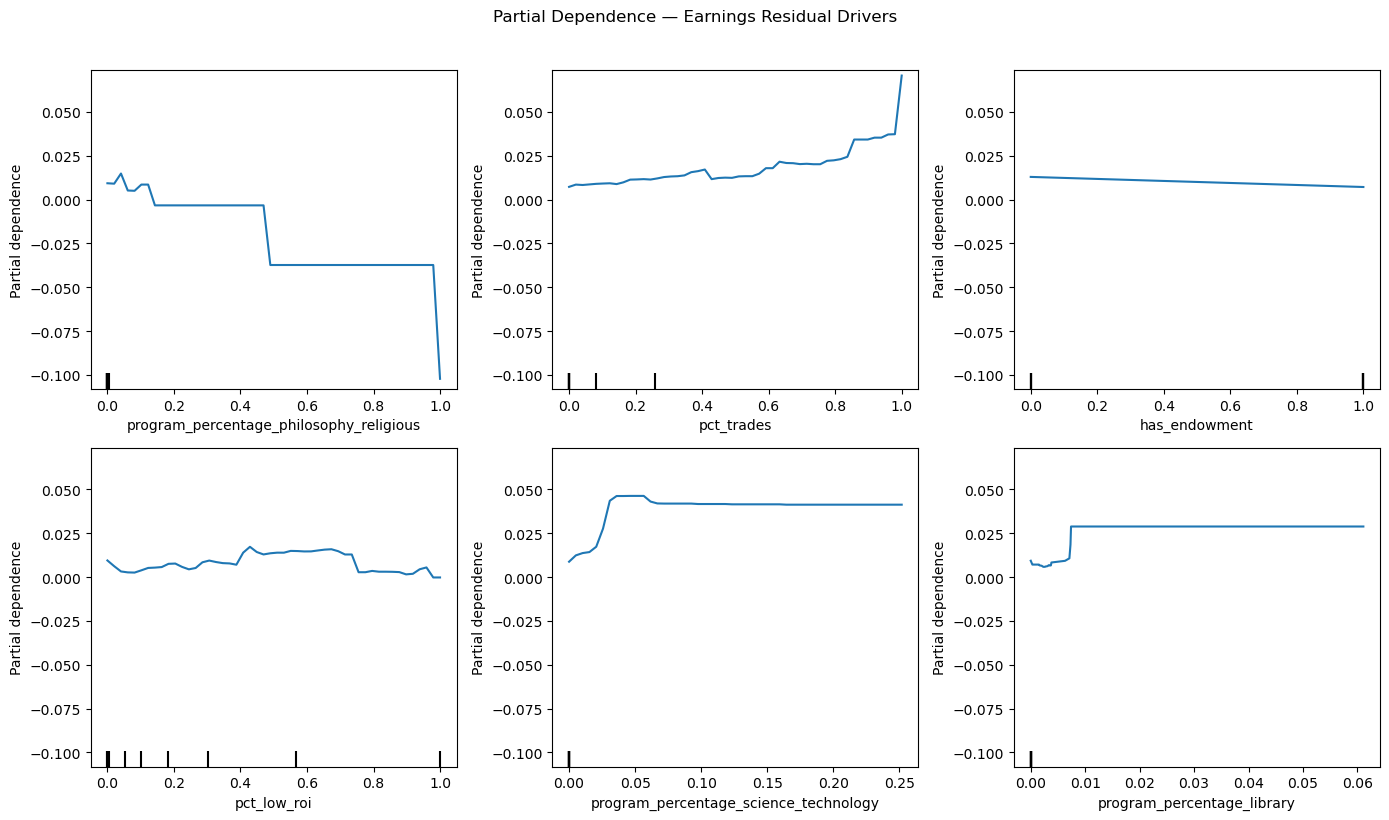

In [187]:
import math

n = len(top_features)
ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
ax_flat = axes.flatten()  

PartialDependenceDisplay.from_estimator(
    pipe_stage2_final,
    X_train[stable_features],
    features=top_features,
    feature_names=stable_features,
    percentiles=(0, 1),  # Look at the absolute min and max
    grid_resolution=50, # Default is 100
    ax=ax_flat
)

plt.suptitle("Partial Dependence — Earnings Residual Drivers", y=1.02)
plt.tight_layout()
plt.savefig("pdp_plot.png", dpi=150, bbox_inches="tight")
plt.show()

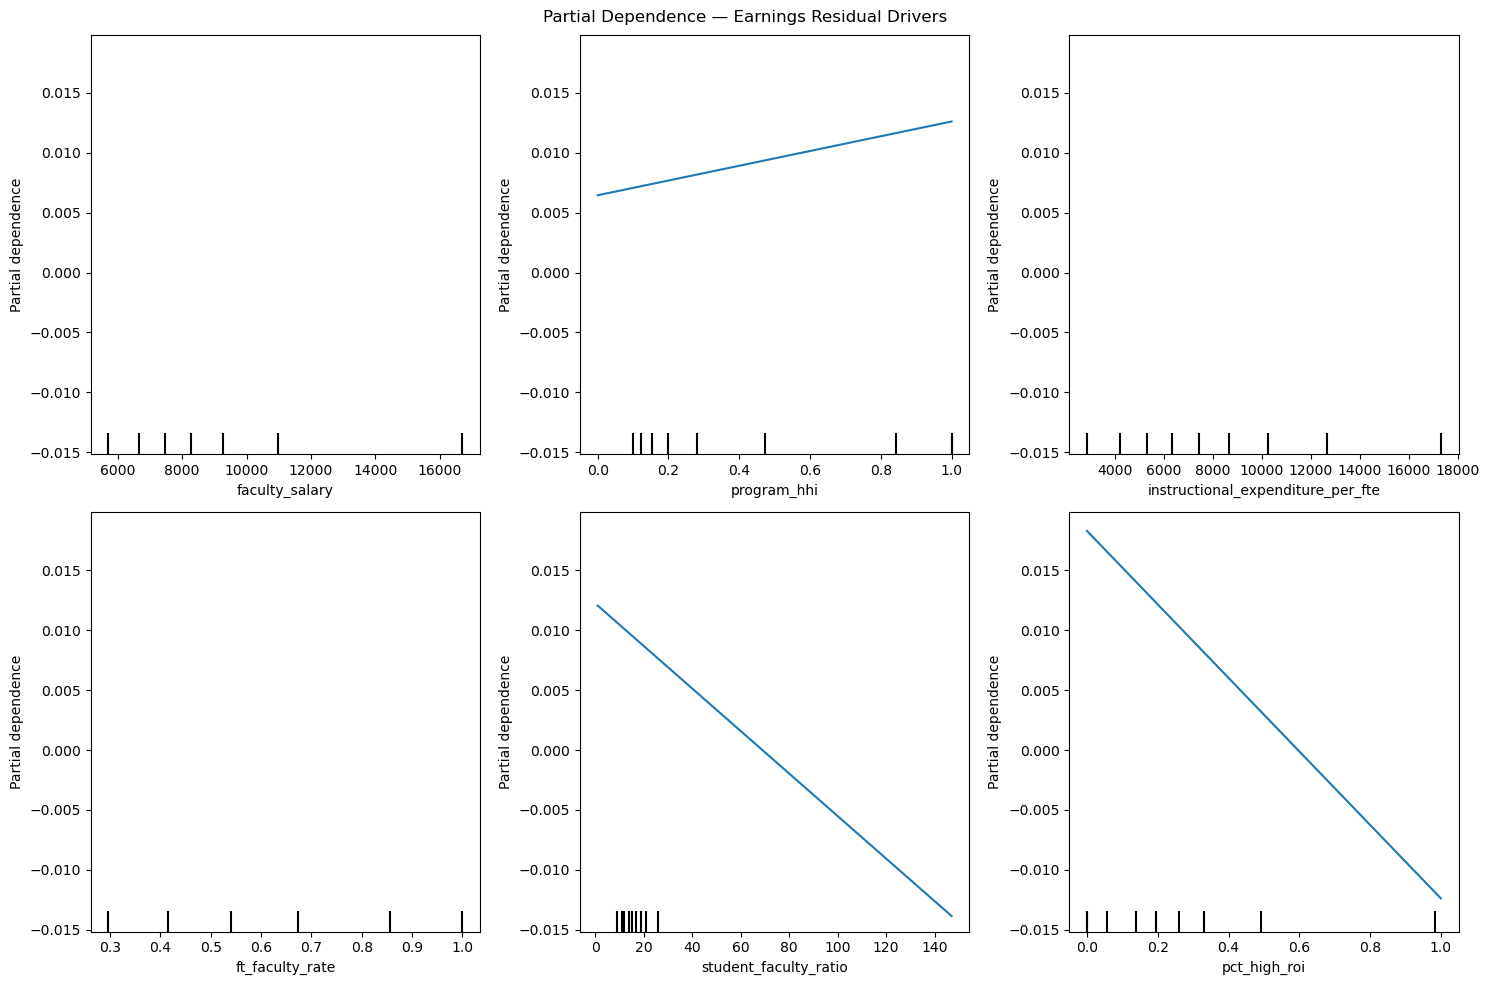

In [190]:
from sklearn.inspection import PartialDependenceDisplay

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle("Partial Dependence — Earnings Residual Drivers")

features_to_plot = [
    "faculty_salary",
    "program_hhi", 
    "instructional_expenditure_per_fte",
    "ft_faculty_rate",
    "student_faculty_ratio",
    "pct_high_roi"
]

PartialDependenceDisplay.from_estimator(
    pipe_final,
    inst_model_df[stable_features],
    features=features_to_plot,
    ax=axes.flatten()[:len(features_to_plot)],
    percentiles=(0, 1),  # Look at the absolute min and max
    grid_resolution=75, # Default is 100
    n_jobs=1
)

plt.tight_layout()
plt.show()

In [191]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.inspection import partial_dependence

def get_pd_data(model, X, feature, percentiles=(0.05, 0.95), grid_resolution=50):
    pd_result = partial_dependence(
        model,
        X,
        features=[feature],
        percentiles=percentiles,
        grid_resolution=grid_resolution,
        kind="average"
    )
    return pd_result["grid_values"][0], pd_result["average"][0]

features_to_plot = {
    "program_hhi":                          "Program Concentration (HHI)",
    "pct_high_roi":                         "% High ROI Programs",
    "program_percentage_philosophy_religious":"Program Percentage of Philosophy and Religion",
    "program_percentage_business_marketing":"% Business & Marketing",
    "student_faculty_ratio":                "Student Faculty Ratio",
    "instructional_expenditure_per_fte":    "Instructional Spend per FTE",
}

n = len(features_to_plot)
cols = 3
rows = (n + cols - 1) // cols

fig = make_subplots(
    rows=rows, cols=cols,
    subplot_titles=list(features_to_plot.values()),
    vertical_spacing=0.15,
    horizontal_spacing=0.08
)

for i, (feat, label) in enumerate(features_to_plot.items()):
    row = i // cols + 1
    col = i % cols + 1

    x_vals, y_vals = get_pd_data(
        pipe_stage2_final,
        X[stable_features],
        feat
    )

    fig.add_trace(
        go.Scatter(
            x=x_vals,
            y=y_vals,
            mode="lines",
            line=dict(color="#2563EB", width=2.5),
            showlegend=False,
            hovertemplate=f"{label}<br>Value: %{{x:.3f}}<br>Residual: %{{y:.4f}}<extra></extra>"
        ),
        row=row, col=col
    )

    fig.add_hline(
        y=np.mean(y_vals),
        line_dash="dot",
        line_color="gray",
        line_width=1,
        row=row, col=col
    )

fig.update_layout(
    title=dict(
        text="Partial Dependence — Earnings Residual Drivers",
        font=dict(size=20),
        x=0.5
    ),
    height=600,
    width=1100,
    plot_bgcolor="white",
    paper_bgcolor="white",
    font=dict(family="Inter, Arial", size=12),
)

fig.update_xaxes(showgrid=True, gridcolor="#f0f0f0", zeroline=False)
fig.update_yaxes(showgrid=True, gridcolor="#f0f0f0", zeroline=False)

fig.show()

# save for presentation
# fig.write_html("partial_dependence.html")
# fig.write_image("partial_dependence.png", scale=2)  # needs kaleido: pip install kaleido

In [192]:
inst_model_df[targ].describe()

count    4327.000000
mean        0.007483
std         0.143179
min        -0.733509
25%        -0.066355
50%         0.005253
75%         0.080913
max         1.139731
Name: average_error_log, dtype: float64

In [194]:
pre_y_over = inst_model_df[targ]

percentiles = [0.1, 0.2, 0.3, 0.7, 0.8, 0.9]
values = np.quantile(pre_y_over, percentiles)

fig = px.histogram(pre_y_over, nbins=100, title="Target Distribution with Percentiles")

for p, v in zip(percentiles, values):
    fig.add_vline(
        x=v,
        line_dash="dash",
        annotation_text=f"{int(p*100)}%",
        annotation_position="top"
    )

fig.show()

In [195]:
inst_model_df[targ].skew()

np.float64(0.303652800142074)

In [216]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_absolute_error, r2_score


# y_raw = np.log1p(inst_model_df[targ])
# y_raw = y.clip(upper=y.quantile(0.95))
y_raw = inst_model_df[targ].copy()

low = y_raw.quantile(0.3)
high = y_raw.quantile(0.65)

mask = (y_raw <= low) | (y_raw >= high)

X_clf = inst_model_df.drop(columns=["unit_id", targ, "weight",'credential_level','code','avg_rank_stability','school_name','average_pred_log'], errors="ignore").loc[mask].copy()
y_clf = (y_raw.loc[mask] >= high).astype(int)
w_clf = inst_model_df['weight'].loc[mask].copy()

X_clf = X_clf.apply(pd.to_numeric, errors="coerce")

X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X_clf,
    y_clf,
    w_clf,
    test_size=0.3,
    random_state=RANDOM_STATE,
    stratify=y_clf
)


num_cols = X_train.columns.tolist()

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), num_cols)
])

In [217]:
from sklearn.base import clone
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

clf = Pipeline([
    ("preprocessor", preprocessor),
    ("logit", LogisticRegression(max_iter=10000))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

auc_scores = []

for train_idx, val_idx in cv.split(X_clf, y_clf):
    X_tr = X_clf.iloc[train_idx]
    X_val = X_clf.iloc[val_idx]
    y_tr = y_clf.iloc[train_idx]
    y_val = y_clf.iloc[val_idx]
    w_tr = w_clf.iloc[train_idx]

    model = clone(clf)
    model.fit(X_tr, y_tr, logit__sample_weight=w_tr)

    val_proba = model.predict_proba(X_val)[:, 1]
    auc_scores.append(roc_auc_score(y_val, val_proba))

print(""" \
        LogisticRegression(max_iter=10000)
""")
print("AUC scores:", [round(s, 4) for s in auc_scores])
print("AUC mean:", round(np.mean(auc_scores), 4))
print("AUC std:", round(np.std(auc_scores), 4))

         LogisticRegression(max_iter=10000)

AUC scores: [0.6575, 0.6562, 0.6285, 0.6822, 0.6847]
AUC mean: 0.6618
AUC std: 0.0205


In [218]:
from sklearn.ensemble import HistGradientBoostingClassifier

clf_hgb = Pipeline([
    ("preprocessor", preprocessor),
    ("logit", HistGradientBoostingClassifier(
        max_depth=3,
        learning_rate=0.05,
        max_iter=200,
        random_state=42
    ))
])

auc_scores = []

for train_idx, val_idx in cv.split(X_clf, y_clf):
    X_tr = X_clf.iloc[train_idx]
    X_val = X_clf.iloc[val_idx]
    y_tr = y_clf.iloc[train_idx]
    y_val = y_clf.iloc[val_idx]
    w_tr = w_clf.iloc[train_idx]

    model = clone(clf_hgb)
    model.fit(X_tr, y_tr, logit__sample_weight=w_tr)

    val_proba = model.predict_proba(X_val)[:, 1]
    auc_scores.append(roc_auc_score(y_val, val_proba))

print(""" \
        HistGradientBoostingClassifier(
        max_depth=3,
        learning_rate=0.05,
        max_iter=200,
        random_state=42
""")
print("AUC scores:", [round(s, 4) for s in auc_scores])
print("AUC mean:", round(np.mean(auc_scores), 4))
print("AUC std:", round(np.std(auc_scores), 4))

         HistGradientBoostingClassifier(
        max_depth=3,
        learning_rate=0.05,
        max_iter=200,
        random_state=42

AUC scores: [0.6769, 0.6753, 0.6866, 0.7123, 0.7188]
AUC mean: 0.694
AUC std: 0.0181


In [219]:
from xgboost import XGBClassifier

xgb_clf = Pipeline([
    ("preprocessor", preprocessor),
    ("logit", XGBClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.01,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=42,
        eval_metric="logloss"
    ))
])

auc_scores = []

for train_idx, val_idx in cv.split(X_clf, y_clf):
    X_tr = X_clf.iloc[train_idx]
    X_val = X_clf.iloc[val_idx]
    y_tr = y_clf.iloc[train_idx]
    y_val = y_clf.iloc[val_idx]
    w_tr = w_clf.iloc[train_idx]

    model = clone(xgb_clf)
    model.fit(X_tr, y_tr, logit__sample_weight=w_tr)

    val_proba = model.predict_proba(X_val)[:, 1]
    auc_scores.append(roc_auc_score(y_val, val_proba))

print(""" \
        XGBClassifier n_estimators=300,
        max_depth=3,
        learning_rate=0.01,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=42,
        eval_metric="logloss"
""")
print("AUC scores:", [round(s, 4) for s in auc_scores])
print("AUC mean:", round(np.mean(auc_scores), 4))
print("AUC std:", round(np.std(auc_scores), 4))

         XGBClassifier n_estimators=300,
        max_depth=3,
        learning_rate=0.01,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=42,
        eval_metric="logloss"

AUC scores: [0.6727, 0.6783, 0.6752, 0.7047, 0.7239]
AUC mean: 0.691
AUC std: 0.0201


In [220]:
C_values = [0.001, 0.01, 0.1, 1, 10, 100]

for C in C_values:
    clf = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("logit", LogisticRegression(C=C, max_iter=10000))
    ])
    
    auc_scores = []
    for train_idx, val_idx in cv.split(X_clf, y_clf):
        X_tr, X_val = X_clf.iloc[train_idx], X_clf.iloc[val_idx]
        y_tr, y_val = y_clf.iloc[train_idx], y_clf.iloc[val_idx]
        w_tr = w_clf.iloc[train_idx]
        
        clone(clf).fit(X_tr, y_tr, logit__sample_weight=w_tr)
        model = clone(clf)
        model.fit(X_tr, y_tr, logit__sample_weight=w_tr)
        auc_scores.append(roc_auc_score(y_val, model.predict_proba(X_val)[:, 1]))
    
    print(f"C={C}: AUC={np.mean(auc_scores):.4f} ± {np.std(auc_scores):.4f}")

C=0.001: AUC=0.6514 ± 0.0237
C=0.01: AUC=0.6609 ± 0.0205
C=0.1: AUC=0.6611 ± 0.0193
C=1: AUC=0.6618 ± 0.0205
C=10: AUC=0.6629 ± 0.0221
C=100: AUC=0.6635 ± 0.0224


In [201]:
import optuna

def objective(trial):
    penalty = trial.suggest_categorical("penalty", ["l1", "l2"])
    class_weight = trial.suggest_categorical("class_weight", [None, "balanced"])
    C = trial.suggest_float("C", 1e-3, 100.0, log=True)
    solver = "liblinear" if penalty == "l1" else trial.suggest_categorical(
        "solver_l2", ["lbfgs", "liblinear"]
    )

    clf = Pipeline([
        ("preprocessor", preprocessor),
        ("logit", LogisticRegression(
            penalty=penalty,
            C=C,
            solver=solver,
            class_weight=class_weight,
            max_iter=10000,
            random_state=42
        ))
    ])

    auc_scores = []
    for train_idx, val_idx in cv.split(X_clf, y_clf):
        X_tr, X_val = X_clf.iloc[train_idx], X_clf.iloc[val_idx]
        y_tr, y_val = y_clf.iloc[train_idx], y_clf.iloc[val_idx]
        w_tr = w_clf.iloc[train_idx]

        model = clone(clf)
        model.fit(X_tr, y_tr, logit__sample_weight=w_tr)
        auc_scores.append(roc_auc_score(y_val, model.predict_proba(X_val)[:, 1]))

    return float(np.mean(auc_scores))

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=40)

print("Best AUC:", study.best_value)
print("Params:", study.best_params)

c:\Users\sebas\miniconda3\envs\roi-fresh\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-04-17 05:00:26,477] A new study created in memory with name: no-name-5e1967c7-fd58-447e-94fa-031e809b35f4
[I 2026-04-17 05:00:26,779] Trial 0 finished with value: 0.6616180536972616 and parameters: {'penalty': 'l1', 'class_weight': 'balanced', 'C': 0.2820286009239396}. Best is trial 0 with value: 0.6616180536972616.
[I 2026-04-17 05:00:36,795] Trial 1 finished with value: 0.6631473797810431 and parameters: {'penalty': 'l1', 'class_weight': None, 'C': 21.176850336692024}. Best is trial 1 with value: 0.6631473797810431.
[I 2026-04-17 05:00:37,078] Trial 2 finished with value: 0.6611487050100913 and parameters: {'penalty': 'l1', 'class_weight': None, 'C': 0.14061256629957103}. Best is trial 1 with value: 0.663147379781043

Best AUC: 0.6632947919086533
Params: {'penalty': 'l2', 'class_weight': None, 'C': 49.23953922332005, 'solver_l2': 'liblinear'}


In [221]:
def objective(trial):
    
    params = {
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "max_depth": trial.suggest_int("max_depth", 2, 6),
        "max_iter": trial.suggest_int("max_iter", 100, 500),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 10, 100),
        "l2_regularization": trial.suggest_float("l2_regularization", 0.0, 5.0),
        "random_state": 42
    }
    
    clf_hgb_o = Pipeline([
        ("preprocessor", preprocessor),   # 👈 your existing imputer+scaler
        ("hgbr", HistGradientBoostingClassifier(**params))
    ])
  
    
    val_scores = []
    train_scores = []
    
    for train_idx, val_idx in cv.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        w_tr = w_train.iloc[train_idx]

        m = clone(clf_hgb_o)
        m.fit(X_tr, y_tr, hgbr__sample_weight=w_tr)
        
        val_scores.append(roc_auc_score(y_val, m.predict_proba(X_val)[:, 1]))
        train_scores.append(roc_auc_score(y_tr, m.predict_proba(X_tr)[:, 1]))

    mean_val = np.mean(val_scores)
    mean_train = np.mean(train_scores)
    gap = mean_train - mean_val

    return mean_val - 0.5 * gap

hgbr_study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42)
)
hgbr_study.optimize(objective, n_trials=40)

print("Best trial:")
print("CV AUC:", hgbr_study.best_value)
print("Params:", hgbr_study.best_params)


best_hgbr_params = hgbr_study.best_params.copy()
best_hgbr_params.update({
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "random_state": 42,
    "n_jobs": -1,
    "tree_method": "hist"
})

best_hgbr = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(**best_hgbr_params))
])

best_hgbr.fit(X_train, y_train, model__sample_weight=w_train)  # ← pipeline fit

hgbr_train_proba = best_hgbr.predict_proba(X_train)[:, 1]
hgbr_test_proba = best_hgbr.predict_proba(X_test)[:, 1]

[I 2026-04-17 05:32:21,850] A new study created in memory with name: no-name-74571072-e8cc-4b5c-89ad-5645e3859aa1
[I 2026-04-17 05:32:25,340] Trial 0 finished with value: 0.5733790935179439 and parameters: {'learning_rate': 0.030710573677773714, 'max_depth': 6, 'max_iter': 393, 'min_samples_leaf': 64, 'l2_regularization': 0.7800932022121826}. Best is trial 0 with value: 0.5733790935179439.
[I 2026-04-17 05:32:27,078] Trial 1 finished with value: 0.6071321789939417 and parameters: {'learning_rate': 0.015957084694148364, 'max_depth': 2, 'max_iter': 447, 'min_samples_leaf': 64, 'l2_regularization': 3.540362888980227}. Best is trial 1 with value: 0.6071321789939417.
[I 2026-04-17 05:32:31,604] Trial 2 finished with value: 0.5662551752291823 and parameters: {'learning_rate': 0.010636066512540286, 'max_depth': 6, 'max_iter': 433, 'min_samples_leaf': 29, 'l2_regularization': 0.9091248360355031}. Best is trial 1 with value: 0.6071321789939417.
[I 2026-04-17 05:32:33,394] Trial 3 finished with 

Best trial:
CV AUC: 0.6135965197469981
Params: {'learning_rate': 0.013214875174737396, 'max_depth': 5, 'max_iter': 183, 'min_samples_leaf': 99, 'l2_regularization': 0.6578161912343937}


In [222]:
import plotly.graph_objects as go
from sklearn.metrics import roc_curve, f1_score, precision_score, recall_score

thresholds = np.linspace(0.01, 0.99, 200)

metrics = {
    "f1": [], "precision": [], "recall": [], "accuracy": []
}

for t in thresholds:
    hgbc_preds = (hgbr_train_proba >= t).astype(int)
    metrics["f1"].append(f1_score(y_train, hgbc_preds, zero_division=0))
    metrics["precision"].append(precision_score(y_train, hgbc_preds, zero_division=0))
    metrics["recall"].append(recall_score(y_train, hgbc_preds, zero_division=0))
    metrics["accuracy"].append(accuracy_score(y_train, hgbc_preds))

best_idx = np.argmax(metrics["f1"])
hgbc_best_thresh = thresholds[best_idx]

fig = go.Figure()

fig.add_trace(go.Scatter(x=thresholds, y=metrics["f1"],
    name="F1", line=dict(color="#636EFA", width=2)))
fig.add_trace(go.Scatter(x=thresholds, y=metrics["precision"],
    name="Precision", line=dict(color="#EF553B", width=2)))
fig.add_trace(go.Scatter(x=thresholds, y=metrics["recall"],
    name="Recall", line=dict(color="#00CC96", width=2)))
fig.add_trace(go.Scatter(x=thresholds, y=metrics["accuracy"],
    name="Accuracy", line=dict(color="#FFA15A", width=2)))

fig.add_vline(
    x=hgbc_best_thresh,
    line_dash="dash",
    line_color="white",
    annotation_text=f"Best F1 threshold: {hgbc_best_thresh:.3f}",
    annotation_position="top right"
)

fig.update_layout(
    title="Threshold vs Classification Metrics (Train)",
    xaxis_title="Threshold",
    yaxis_title="Score",
    legend=dict(orientation="h", y=-0.15),
    template="plotly_dark",
    hovermode="x unified"
)

fig.show()
print(f"\nBest F1 threshold: {hgbc_best_thresh:.4f}")
print(f"At this threshold — F1: {metrics['f1'][best_idx]:.4f} | "
      f"Precision: {metrics['precision'][best_idx]:.4f} | "
      f"Recall: {metrics['recall'][best_idx]:.4f}")


Best F1 threshold: 0.4778
At this threshold — F1: 0.8020 | Precision: 0.7138 | Recall: 0.9151


In [ ]:
from sklearn.metrics import log_loss

hgbr_train_pred = (hgbr_train_proba >= hgbc_best_thresh).astype(int)
hgbr_test_pred = (hgbr_test_proba >= hgbc_best_thresh).astype(int)

train_auc = roc_auc_score(y_train, hgbr_train_proba, sample_weight=w_train)
test_auc = roc_auc_score(y_test, hgbr_test_proba, sample_weight=w_test)

train_acc = accuracy_score(y_train, hgbr_train_pred)
test_acc = accuracy_score(y_test, hgbr_test_pred)

train_logloss = log_loss(y_train, hgbr_train_proba, sample_weight=w_train)
test_logloss = log_loss(y_test, hgbr_test_proba, sample_weight=w_test)

print("\nHGBClassifier")
print("Train AUC:", round(train_auc, 4))
print("Test AUC:", round(test_auc, 4))
print("Train Accuracy:", round(train_acc, 4))
print("Test Accuracy:", round(test_acc, 4))
print("Train LogLoss:", round(train_logloss, 4))
print("Test LogLoss:", round(test_logloss, 4))

print("\nConfusion Matrix (Test):")
print(confusion_matrix(y_test, hgbr_test_pred))

print("\nClassification Report (Test):")
print(classification_report(y_test, hgbr_test_pred, digits=4))


HGBClassifier
Train AUC: 0.8548
Test AUC: 0.707
Train Accuracy: 0.7598
Test Accuracy: 0.6469
Train LogLoss: 0.5724
Test LogLoss: 0.6347

Confusion Matrix (Test):
[[182 207]
 [ 91 364]]

Classification Report (Test):
              precision    recall  f1-score   support

           0     0.6667    0.4679    0.5498       389
           1     0.6375    0.8000    0.7096       455

    accuracy                         0.6469       844
   macro avg     0.6521    0.6339    0.6297       844
weighted avg     0.6509    0.6469    0.6359       844



In [ ]:
from sklearn.metrics import roc_curve, f1_score, precision_score, recall_score

fpr, tpr, thresholds = roc_curve(y_train, hgbr_train_proba)

best_thresh = 0.5
best_f1 = 0

for t in thresholds:
    preds = (hgbr_train_proba >= t).astype(int)
    f1 = f1_score(y_train, preds)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

print(f"Optimal threshold: {best_thresh:.4f}")

test_pred_tuned = (hgbr_test_proba >= best_thresh).astype(int)

print("\nTuned threshold metrics:")
print(confusion_matrix(y_test, test_pred_tuned))
print(classification_report(y_test, test_pred_tuned, digits=4))

Optimal threshold: 0.4806

Tuned threshold metrics:
[[182 207]
 [ 91 364]]
              precision    recall  f1-score   support

           0     0.6667    0.4679    0.5498       389
           1     0.6375    0.8000    0.7096       455

    accuracy                         0.6469       844
   macro avg     0.6521    0.6339    0.6297       844
weighted avg     0.6509    0.6469    0.6359       844



In [ ]:
from sklearn.metrics import average_precision_score, f1_score

hgbc_train_ap = average_precision_score(y_train, hgbr_train_proba, sample_weight=w_train)
hgbc_test_ap = average_precision_score(y_test, hgbr_test_proba, sample_weight=w_test)
hgbc_train_f1 = f1_score(y_train, hgbr_train_pred, sample_weight=w_train)
hgbc_test_f1 = f1_score(y_test, hgbr_test_pred, sample_weight=w_test)

print("Train AP:", round(hgbc_train_ap, 4))
print("Test AP:", round(hgbc_test_ap, 4))
print("Train F1:", round(hgbc_train_f1, 4))
print("Test F1:", round(hgbc_test_f1, 4))

Train AP: 0.8741
Test AP: 0.73
Train F1: 0.8031
Test F1: 0.7099


In [228]:
kf_cv = KFold(n_splits=5, shuffle=True, random_state=42)

def objective(trial):
    params = {
    # Using log=True is smart here for learning rate
    "learning_rate": trial.suggest_float("learning_rate", 0.001, 0.2, log=True),
    "max_depth": trial.suggest_int("max_depth", 5, 7),
    
    # Corrected parameter names for XGBoost
    "n_estimators": trial.suggest_int("n_estimators", 100, 500), 
    "subsample": trial.suggest_float("subsample", 0.6, 0.8),
    
    
    "tree_method": 'hist',
    "device": 'cuda',
    "random_state": RANDOM_STATE,
}

    xgbr_o = Pipeline([
        ("preprocessor", preprocessor),
        ("reg", XGBRegressor(**params)) # Changed step name to 'reg' for clarity
    ])

    r2_scores = []
    for train_idx, val_idx in kf_cv.split(X, y):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
        w_tr = w.iloc[train_idx]

        model = clone(xgbr_o)
        model.fit(X_tr, y_tr, reg__sample_weight=w_tr)

        preds = model.predict(X_val)
        r2_scores.append(r2_score(y_val, preds))

    return float(np.mean(r2_scores))

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20, n_jobs=2)

print("Best trial:")
print("R2:", study.best_value)
print("Params:", study.best_params)

[I 2026-04-17 05:50:11,770] A new study created in memory with name: no-name-08628e61-d4e8-45af-9da3-58a497a2c873
[I 2026-04-17 05:50:16,509] Trial 0 finished with value: 0.09714127209759842 and parameters: {'learning_rate': 0.012314722562276378, 'max_depth': 6, 'n_estimators': 145, 'subsample': 0.6952196308574947}. Best is trial 0 with value: 0.09714127209759842.
[I 2026-04-17 05:50:21,606] Trial 1 finished with value: 0.023077984360890126 and parameters: {'learning_rate': 0.10768287624847846, 'max_depth': 6, 'n_estimators': 333, 'subsample': 0.7602961868688094}. Best is trial 0 with value: 0.09714127209759842.
[I 2026-04-17 05:50:25,271] Trial 2 finished with value: 0.12783781962607516 and parameters: {'learning_rate': 0.03911889265805533, 'max_depth': 5, 'n_estimators': 373, 'subsample': 0.6301217469247553}. Best is trial 2 with value: 0.12783781962607516.
[I 2026-04-17 05:50:31,627] Trial 4 finished with value: 0.033368825285327565 and parameters: {'learning_rate': 0.00148816148807

Best trial:
R2: 0.12783781962607516
Params: {'learning_rate': 0.03911889265805533, 'max_depth': 5, 'n_estimators': 373, 'subsample': 0.6301217469247553}


In [229]:
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 600),
        "max_depth": trial.suggest_int("max_depth", 2, 6),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.1, log=True),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 15),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 0.5, 3.0),

        # fixed
        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "random_state": RANDOM_STATE,
        "device": 'cuda',
        "tree_method": "hist"
    }
    
    model = Pipeline([
        ('preprocessor', preprocessor),
        ('model', XGBClassifier(**params))
    ])

    val_scores = []
    train_scores = []
    
    for train_idx, val_idx in cv.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        w_tr = w_train.iloc[train_idx]

        m = clone(model)
        m.fit(X_tr, y_tr, model__sample_weight=w_tr)
        
        val_scores.append(roc_auc_score(y_val, m.predict_proba(X_val)[:, 1]))
        train_scores.append(roc_auc_score(y_tr, m.predict_proba(X_tr)[:, 1]))

    mean_val = np.mean(val_scores)
    mean_train = np.mean(train_scores)
    gap = mean_train - mean_val

    return mean_val - 0.5 * gap

xgb_study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42)
)
xgb_study.optimize(objective, n_trials=100, n_jobs=2)

print("Best trial:")
print("CV AUC:", xgb_study.best_value)
print("Params:", xgb_study.best_params)

best_params = xgb_study.best_params.copy()
best_params.update({
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "random_state": 42,
    "n_jobs": -1,
    "tree_method": "hist"
})

best_xgb = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(**best_params))
])

best_xgb.fit(X_train, y_train, model__sample_weight=w_train)  # ← pipeline fit


[I 2026-04-17 05:53:17,762] A new study created in memory with name: no-name-305d9f7c-afdb-4333-9fb5-1e9df5b0096d
[I 2026-04-17 05:53:23,098] Trial 0 finished with value: 0.6096317512324172 and parameters: {'n_estimators': 583, 'max_depth': 2, 'learning_rate': 0.03979955713977629, 'min_child_weight': 14, 'subsample': 0.9996723425230182, 'colsample_bytree': 0.7968556521183667, 'reg_alpha': 0.6177774322256739, 'reg_lambda': 0.00033067757258438857, 'gamma': 4.578896005488066, 'scale_pos_weight': 2.2637228818076816}. Best is trial 0 with value: 0.6096317512324172.
[I 2026-04-17 05:53:27,035] Trial 2 finished with value: 0.6091062389717274 and parameters: {'n_estimators': 361, 'max_depth': 2, 'learning_rate': 0.005014658803912272, 'min_child_weight': 7, 'subsample': 0.9134183154880993, 'colsample_bytree': 0.8014283165802145, 'reg_alpha': 0.0019679092067015403, 'reg_lambda': 2.4971348829789877, 'gamma': 0.7217780745411806, 'scale_pos_weight': 1.8723799736732387}. Best is trial 0 with value: 

Best trial:
CV AUC: 0.6262563938879679
Params: {'n_estimators': 177, 'max_depth': 6, 'learning_rate': 0.008700521064586986, 'min_child_weight': 13, 'subsample': 0.6505405054574402, 'colsample_bytree': 0.6838825891522462, 'reg_alpha': 0.050211381801699456, 'reg_lambda': 0.0023311950142686686, 'gamma': 2.286573611347804, 'scale_pos_weight': 1.0312590440532896}


,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [237]:
train_proba = best_xgb.predict_proba(X_train)[:, 1]
test_proba = best_xgb.predict_proba(X_test)[:, 1]

train_pred = (train_proba >= 0.5).astype(int)
test_pred = (test_proba >= 0.5).astype(int)


train_auc = roc_auc_score(y_train, train_proba, sample_weight=w_train)
test_auc = roc_auc_score(y_test, test_proba, sample_weight=w_test)

train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

train_logloss = log_loss(y_train, train_proba, sample_weight=w_train)
test_logloss = log_loss(y_test, test_proba, sample_weight=w_test)

print("\nXGBClassifier")
print("Train AUC:", round(train_auc, 4))
print("Test AUC:", round(test_auc, 4))
print("Train Accuracy:", round(train_acc, 4))
print("Test Accuracy:", round(test_acc, 4))
print("Train LogLoss:", round(train_logloss, 4))
print("Test LogLoss:", round(test_logloss, 4))

print("\nConfusion Matrix (Test):")
print(confusion_matrix(y_test, test_pred))

print("\nClassification Report (Test):")
print(classification_report(y_test, test_pred, digits=4))


XGBClassifier
Train AUC: 0.8018
Test AUC: 0.7144
Train Accuracy: 0.712
Test Accuracy: 0.6564
Train LogLoss: 0.5982
Test LogLoss: 0.6333

Confusion Matrix (Test):
[[204 185]
 [105 350]]

Classification Report (Test):
              precision    recall  f1-score   support

           0     0.6602    0.5244    0.5845       389
           1     0.6542    0.7692    0.7071       455

    accuracy                         0.6564       844
   macro avg     0.6572    0.6468    0.6458       844
weighted avg     0.6570    0.6564    0.6506       844



In [233]:
import plotly.graph_objects as go
from sklearn.metrics import roc_curve, f1_score, precision_score, recall_score

thresholds = np.linspace(0.01, 0.99, 200)

metrics = {
    "f1": [], "precision": [], "recall": [], "accuracy": []
}

for t in thresholds:
    preds = (train_proba >= t).astype(int)
    metrics["f1"].append(f1_score(y_train, preds, zero_division=0))
    metrics["precision"].append(precision_score(y_train, preds, zero_division=0))
    metrics["recall"].append(recall_score(y_train, preds, zero_division=0))
    metrics["accuracy"].append(accuracy_score(y_train, preds))

best_idx = np.argmax(metrics["f1"])
best_thresh = thresholds[best_idx]

fig = go.Figure()

fig.add_trace(go.Scatter(x=thresholds, y=metrics["f1"],
    name="F1", line=dict(color="#636EFA", width=2)))
fig.add_trace(go.Scatter(x=thresholds, y=metrics["precision"],
    name="Precision", line=dict(color="#EF553B", width=2)))
fig.add_trace(go.Scatter(x=thresholds, y=metrics["recall"],
    name="Recall", line=dict(color="#00CC96", width=2)))
fig.add_trace(go.Scatter(x=thresholds, y=metrics["accuracy"],
    name="Accuracy", line=dict(color="#FFA15A", width=2)))

fig.add_vline(
    x=best_thresh,
    line_dash="dash",
    line_color="white",
    annotation_text=f"Best F1 threshold: {best_thresh:.3f}",
    annotation_position="top right"
)

fig.update_layout(
    title="Threshold vs Classification Metrics (Train)",
    xaxis_title="Threshold",
    yaxis_title="Score",
    legend=dict(orientation="h", y=-0.15),
    template="plotly_dark",
    hovermode="x unified"
)

fig.show()
print(f"\nBest F1 threshold: {best_thresh:.4f}")
print(f"At this threshold — F1: {metrics['f1'][best_idx]:.4f} | "
      f"Precision: {metrics['precision'][best_idx]:.4f} | "
      f"Recall: {metrics['recall'][best_idx]:.4f}")

# apply to test
test_pred_tuned = (test_proba >= best_thresh).astype(int)
print(f"\nTest set with tuned threshold ({best_thresh:.3f}):")
print(confusion_matrix(y_test, test_pred_tuned))
print(classification_report(y_test, test_pred_tuned, digits=4))


Best F1 threshold: 0.4778
At this threshold — F1: 0.7716 | Precision: 0.6706 | Recall: 0.9085

Test set with tuned threshold (0.478):
[[172 217]
 [ 74 381]]
              precision    recall  f1-score   support

           0     0.6992    0.4422    0.5417       389
           1     0.6371    0.8374    0.7236       455

    accuracy                         0.6552       844
   macro avg     0.6682    0.6398    0.6327       844
weighted avg     0.6657    0.6552    0.6398       844



In [234]:
from sklearn.metrics import average_precision_score, f1_score, roc_curve

train_ap = average_precision_score(y_train, train_proba, sample_weight=w_train)
test_ap = average_precision_score(y_test, test_proba, sample_weight=w_test)
train_f1 = f1_score(y_train, train_pred, sample_weight=w_train)
test_f1 = f1_score(y_test, test_pred, sample_weight=w_test)

print("Train AP:", round(train_ap, 4))
print("Test AP:", round(test_ap, 4))
print("Train F1:", round(train_f1, 4))
print("Test F1:", round(test_f1, 4))

Train AP: 0.8231
Test AP: 0.7377
Train F1: 0.7618
Test F1: 0.7073


In [235]:
fpr, tpr, thresholds = roc_curve(y_train, train_proba)

best_thresh = 0.5
best_f1 = 0

for t in thresholds:
    preds = (train_proba >= t).astype(int)
    f1 = f1_score(y_train, preds)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

print(f"Optimal threshold: {best_thresh:.4f}")

test_pred_tuned = (test_proba >= best_thresh).astype(int)

print("\nTuned threshold metrics:")
print(confusion_matrix(y_test, test_pred_tuned))
print(classification_report(y_test, test_pred_tuned, digits=4))

Optimal threshold: 0.4774

Tuned threshold metrics:
[[172 217]
 [ 73 382]]
              precision    recall  f1-score   support

           0     0.7020    0.4422    0.5426       389
           1     0.6377    0.8396    0.7249       455

    accuracy                         0.6564       844
   macro avg     0.6699    0.6409    0.6337       844
weighted avg     0.6674    0.6564    0.6408       844



In [242]:
w_xgb, w_hgb = 0.6, 0.4
ensemble_train_proba = w_xgb * train_proba + w_hgb * hgbr_train_proba
ensemble_test_proba = w_xgb * test_proba + w_hgb * hgbr_test_proba

In [255]:
# ensemble_train_proba = best_xgb.predict_proba(X_train)[:, 1]
# ensemble_test_proba = best_xgb.predict_proba(X_test)[:, 1]

train_pred = (ensemble_train_proba >= 0.488).astype(int)
test_pred = (ensemble_test_proba >= 0.488).astype(int)

train_auc = roc_auc_score(y_train, ensemble_train_proba, sample_weight=w_train)
test_auc = roc_auc_score(y_test, ensemble_test_proba, sample_weight=w_test)

train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

train_logloss = log_loss(y_train, ensemble_train_proba, sample_weight=w_train)
test_logloss = log_loss(y_test, ensemble_test_proba, sample_weight=w_test)

print("\nEnsemble")
print("Train AUC:", round(train_auc, 4))
print("Test AUC:", round(test_auc, 4))
print("Train Accuracy:", round(train_acc, 4))
print("Test Accuracy:", round(test_acc, 4))
print("Train LogLoss:", round(train_logloss, 4))
print("Test LogLoss:", round(test_logloss, 4))

print("\nConfusion Matrix (Test):")
print(confusion_matrix(y_test, test_pred))

print("\nClassification Report (Test):")
print(classification_report(y_test, test_pred, digits=4))


Ensemble
Train AUC: 0.8311
Test AUC: 0.7167
Train Accuracy: 0.7379
Test Accuracy: 0.6469
Train LogLoss: 0.5869
Test LogLoss: 0.6329

Confusion Matrix (Test):
[[186 203]
 [ 95 360]]

Classification Report (Test):
              precision    recall  f1-score   support

           0     0.6619    0.4781    0.5552       389
           1     0.6394    0.7912    0.7073       455

    accuracy                         0.6469       844
   macro avg     0.6507    0.6347    0.6312       844
weighted avg     0.6498    0.6469    0.6372       844



In [245]:
import plotly.graph_objects as go
from sklearn.metrics import roc_curve, f1_score, precision_score, recall_score

thresholds = np.linspace(0.01, 0.99, 200)

metrics = {
    "f1": [], "precision": [], "recall": [], "accuracy": []
}

for t in thresholds:
    preds = (ensemble_train_proba >= t).astype(int)
    metrics["f1"].append(f1_score(y_train, preds, zero_division=0))
    metrics["precision"].append(precision_score(y_train, preds, zero_division=0))
    metrics["recall"].append(recall_score(y_train, preds, zero_division=0))
    metrics["accuracy"].append(accuracy_score(y_train, preds))

best_idx = np.argmax(metrics["f1"])
best_thresh = thresholds[best_idx]

fig = go.Figure()

fig.add_trace(go.Scatter(x=thresholds, y=metrics["f1"],
    name="F1", line=dict(color="#636EFA", width=2)))
fig.add_trace(go.Scatter(x=thresholds, y=metrics["precision"],
    name="Precision", line=dict(color="#EF553B", width=2)))
fig.add_trace(go.Scatter(x=thresholds, y=metrics["recall"],
    name="Recall", line=dict(color="#00CC96", width=2)))
fig.add_trace(go.Scatter(x=thresholds, y=metrics["accuracy"],
    name="Accuracy", line=dict(color="#FFA15A", width=2)))

fig.add_vline(
    x=best_thresh,
    line_dash="dash",
    line_color="white",
    annotation_text=f"Best F1 threshold: {best_thresh:.3f}",
    annotation_position="top right"
)

fig.update_layout(
    title="Threshold vs Classification Metrics (Train)",
    xaxis_title="Threshold",
    yaxis_title="Score",
    legend=dict(orientation="h", y=-0.15),
    template="plotly_dark",
    hovermode="x unified"
)

fig.show()
print(f"\nBest F1 threshold: {best_thresh:.4f}")
print(f"At this threshold — F1: {metrics['f1'][best_idx]:.4f} | "
      f"Precision: {metrics['precision'][best_idx]:.4f} | "
      f"Recall: {metrics['recall'][best_idx]:.4f}")

test_pred_tuned = (ensemble_test_proba >= best_thresh).astype(int)
print('Ensemble')
print(f"\nTest set with tuned threshold ({best_thresh:.3f}):")
print(confusion_matrix(y_test, test_pred_tuned))
print(classification_report(y_test, test_pred_tuned, digits=4))


Best F1 threshold: 0.4877
At this threshold — F1: 0.7866 | Precision: 0.6992 | Recall: 0.8991
Ensemble

Test set with tuned threshold (0.488):
[[186 203]
 [ 95 360]]
              precision    recall  f1-score   support

           0     0.6619    0.4781    0.5552       389
           1     0.6394    0.7912    0.7073       455

    accuracy                         0.6469       844
   macro avg     0.6507    0.6347    0.6312       844
weighted avg     0.6498    0.6469    0.6372       844



In [247]:
fpr, tpr, thresholds = roc_curve(y_train, train_proba)

best_thresh = 0.5
best_f1 = 0

for t in thresholds:
    preds = (ensemble_train_proba >= t).astype(int)
    f1 = f1_score(y_train, preds)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

print(f"Optimal threshold: {best_thresh:.4f}")

test_pred_tuned = (ensemble_test_proba >= best_thresh).astype(int)

print("\nTuned threshold metrics:")
print(confusion_matrix(y_test, test_pred_tuned))
print(classification_report(y_test, test_pred_tuned, digits=4))

Optimal threshold: 0.4888

Tuned threshold metrics:
[[186 203]
 [ 97 358]]
              precision    recall  f1-score   support

           0     0.6572    0.4781    0.5536       389
           1     0.6381    0.7868    0.7047       455

    accuracy                         0.6445       844
   macro avg     0.6477    0.6325    0.6291       844
weighted avg     0.6469    0.6445    0.6351       844

